<a href="https://colab.research.google.com/github/tiwariaadarsh-creator/Integrated-Retail-Analytics-For-Store-Optimization/blob/main/Integrated_Retail_Analytics_for_Store_Optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Integrated Retail Analytics for Store Optimization**    



##### **Project Type**    - EDA/Unsupervised
##### **Contribution**    - Individual
##### **Team Member -** Aadarsh Tiwari


# **Project Summary**

### **Objective**
To leverage advanced machine learning and data analytics to optimize retail store performance, accurately forecast demand, and drive customer engagement through strategic segmentation.

---

### **Key Project Components**

*   **🚨 Anomaly Detection:** Identifying unusual sales patterns and investigating external drivers like holidays or economic indicators to clean and validate data.
*   **📈 Time-Series Analysis:** Detecting seasonal variations and holiday effects to understand department-level performance over time.
*   **🛠️ Feature Engineering:** Addressing missing values (specifically in MarkDown data) and creating influential features such as regional factors and store attributes.
*   **👥 Customer & Store Segmentation:** Clustering departments based on sales characteristics to tailor marketing and operational strategies.
*   **🛒 Market Basket Insights:** Inferring product associations at the department level to develop effective cross-selling strategies.
*   **🔮 Demand Forecasting:** Building predictive models for weekly sales incorporating CPI, fuel prices, and unemployment rates.
*   **💡 Strategy Formulation:** Translating data insights into actionable plans for inventory management and personalized markdown strategies.

# **GitHub Link -**

https://github.com/tiwariaadarsh-creator/Integrated-Retail-Analytics-For-Store-Optimization.git

# **Problem Statement**


### **Business Context**

Retailers today face significant challenges in managing diverse inventory across multiple locations while contending with fluctuating economic factors and consumer behaviors. The ability to accurately predict demand and identify operational anomalies is critical for maintaining profitability and customer satisfaction.Our main goal being able to build an integrated analytics framework that utilizes machine learning for anomaly detection, customer/store segmentation, and demand forecasting, ultimately providing a data-driven strategy for store optimization and inventory management.

### **The Problem**
The core challenge lies in extracting actionable insights from complex retail data that includes sales figures, markdowns, and macroeconomic indicators (CPI, Fuel Prices, Unemployment). Specifically, the project addresses:

1.  **Sales Volatility:** Identifying and investigating anomalies in sales patterns caused by holidays or economic shifts.
2.  **Inventory & Demand Inefficiency:** Reducing stockouts and overstock situations through high-precision weekly sales forecasting at the store and department level.
3.  **One-Size-Fits-All Marketing:** Moving away from generic promotions by segmenting stores and departments to enable personalized markdown strategies.
4.  **External Sensitivity:** Quantifying the impact of regional climate and economic trends on consumer purchasing power to improve model robustness.


# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [63]:
import warnings
warnings.filterwarnings('ignore')


# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from datetime import datetime
import datetime as dt
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score, KFold
from sklearn import metrics
# Additional libraries for Retail Analysis
import plotly.express as px
import plotly.graph_objects as go
from scipy import stats
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from mlxtend.frequent_patterns import apriori, association_rules
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

### Dataset Loading

In [64]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [65]:
# Load Datasets

features = pd.read_csv('/content/drive/MyDrive/Features data set.csv')
sales = pd.read_csv('/content/drive/MyDrive/sales data-set.csv')
stores = pd.read_csv('/content/drive/MyDrive/stores data-set.csv')


### Dataset First View

In [66]:
# Dataset First Look
features.head()

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,05/02/2010,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,12/02/2010,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,19/02/2010,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,26/02/2010,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,05/03/2010,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


In [67]:
sales.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,05/02/2010,24924.50,False
1,1,1,12/02/2010,46039.49,True
2,1,1,19/02/2010,41595.55,False
3,1,1,26/02/2010,19403.54,False
4,1,1,05/03/2010,21827.90,False


In [68]:
stores.head()

,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875


### Dataset Rows & Columns count

In [69]:
# Datasets Rows & Columns count
print(f'Features Dataframe Rows: {features.shape[0]}')
print(f'Features Dataframe Columns: {features.shape[1]}')
print(f'Sales Dataframe Rows: {sales.shape[0]}')
print(f'Sales Dataframe Columns: {sales.shape[1]}')
print(f'Stores Dataframe Rows: {stores.shape[0]}')
print(f'Stores Dataframe Columns: {stores.shape[1]}')

Features Dataframe Rows: 8190
Features Dataframe Columns: 12
Sales Dataframe Rows: 421570
Sales Dataframe Columns: 5
Stores Dataframe Rows: 45
Stores Dataframe Columns: 3


### Dataset Information

In [70]:
# Datasets Info
features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8190 entries, 0 to 8189
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         8190 non-null   int64  
 1   Date          8190 non-null   object 
 2   Temperature   8190 non-null   float64
 3   Fuel_Price    8190 non-null   float64
 4   MarkDown1     4032 non-null   float64
 5   MarkDown2     2921 non-null   float64
 6   MarkDown3     3613 non-null   float64
 7   MarkDown4     3464 non-null   float64
 8   MarkDown5     4050 non-null   float64
 9   CPI           7605 non-null   float64
 10  Unemployment  7605 non-null   float64
 11  IsHoliday     8190 non-null   bool   
dtypes: bool(1), float64(9), int64(1), object(1)
memory usage: 712.0+ KB


In [71]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
dtypes: bool(1), float64(1), int64(2), object(1)
memory usage: 13.3+ MB


In [72]:
stores.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Store   45 non-null     int64 
 1   Type    45 non-null     object
 2   Size    45 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 1.2+ KB


#### Duplicate Values

In [73]:
# Dataset Duplicate Value Count
print(f'Duplicate Values in Features Dataframe: {features.duplicated().sum()}')
print(f'Duplicate Values in Sales Dataframe: {sales.duplicated().sum()}')
print(f'Duplicate Values in Stores Dataframe: {stores.duplicated().sum()}')

Duplicate Values in Features Dataframe: 0
Duplicate Values in Sales Dataframe: 0
Duplicate Values in Stores Dataframe: 0


#### Missing Values/Null Values

In [74]:
# Missing Values/Null Values Count
print(features.isna().sum())
print(sales.isna().sum())
print(stores.isna().sum())

Store              0
Date               0
Temperature        0
Fuel_Price         0
MarkDown1       4158
MarkDown2       5269
MarkDown3       4577
MarkDown4       4726
MarkDown5       4140
CPI              585
Unemployment     585
IsHoliday          0
dtype: int64
Store           0
Dept            0
Date            0
Weekly_Sales    0
IsHoliday       0
dtype: int64
Store    0
Type     0
Size     0
dtype: int64


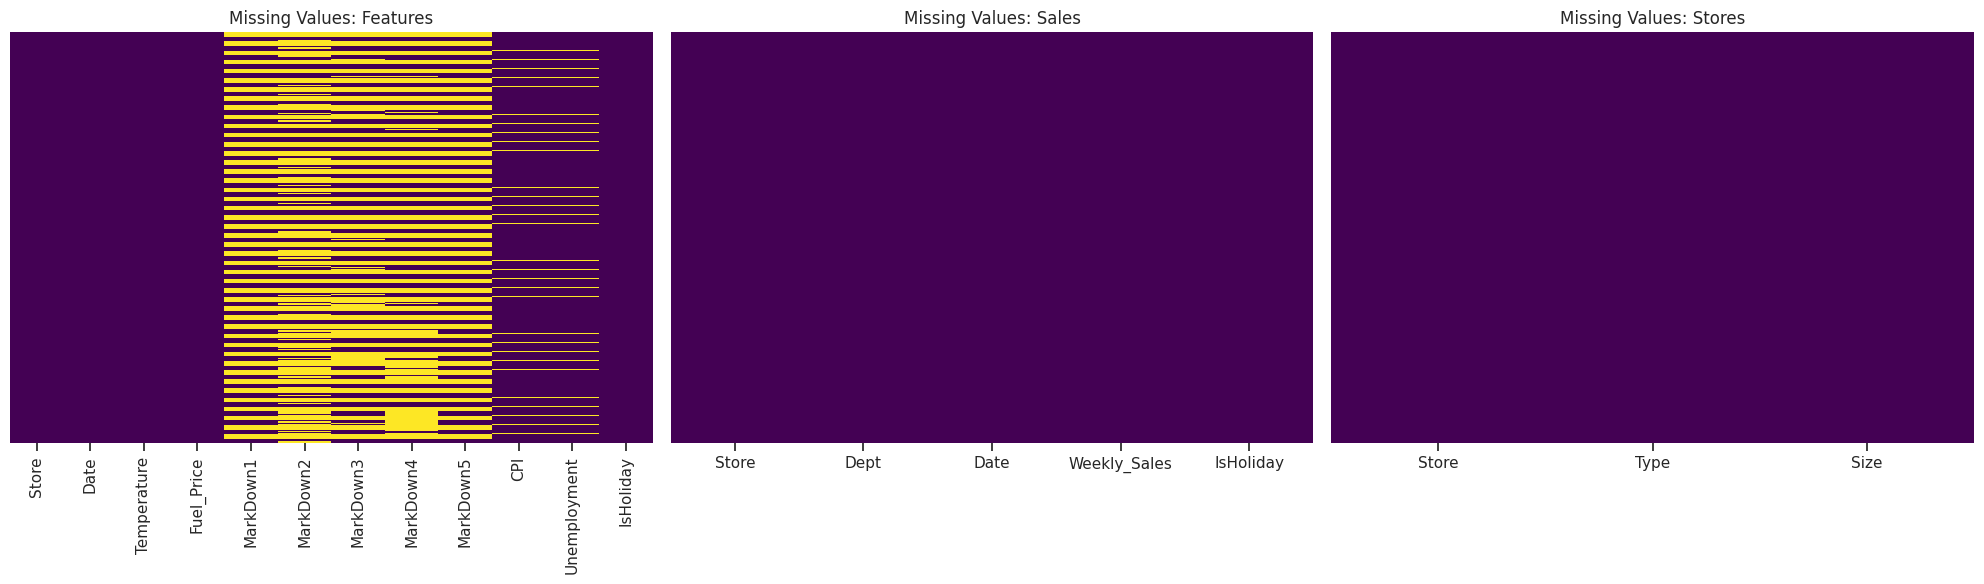

In [75]:
# Visualizing missing values using heatmaps for better clarity
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Features Dataset
sns.heatmap(features.isnull(), yticklabels=False, cbar=False, cmap='viridis', ax=axes[0])
axes[0].set_title('Missing Values: Features')

# Sales Dataset
sns.heatmap(sales.isnull(), yticklabels=False, cbar=False, cmap='viridis', ax=axes[1])
axes[1].set_title('Missing Values: Sales')

# Stores Dataset
sns.heatmap(stores.isnull(), yticklabels=False, cbar=False, cmap='viridis', ax=axes[2])
axes[2].set_title('Missing Values: Stores')

plt.tight_layout()
plt.show()

### What did you know about your dataset?

Based on the initial exploration, here is what we know about the datasets:

1.  **Dataset Structure:**
    *   **Features:** Contains 8,190 entries and 12 columns. It holds environmental and economic data (Temperature, Fuel Price, CPI, Unemployment) linked to stores and dates.
    *   **Sales:** The largest dataset with 421,570 entries and 5 columns, tracking weekly sales per store and department.
    *   **Stores:** A small lookup table with 45 entries and 3 columns defining the type and size of each store.

2.  **Missing Values:**
    *   The **Features** dataset has significant gaps, particularly in the `MarkDown1-5` columns (over 50% missing). `CPI` and `Unemployment` also have approximately 585 missing values each, which will require imputation.
    *   The **Sales** and **Stores** datasets are clean with zero null values.

3.  **Data Quality:**
    *   There are **no duplicate records** across any of the three dataframes.
    *   The `Date` column in both Features and Sales is currently an `object` (string) type and will need to be converted to `datetime` objects for time-series analysis.

4.  **Key Variables:**
    *   The primary keys for merging these datasets will be `Store` and `Date` (between Features and Sales) and `Store` (between Sales and Stores).

## ***2. Understanding Your Variables***

In [76]:
# Displaying dataset columns as DataFrames for better visualization
print("--- Features Columns ---")
display(pd.DataFrame(features.columns, columns=['Column Name']))

print("\n--- Sales Columns ---")
display(pd.DataFrame(sales.columns, columns=['Column Name']))

print("\n--- Stores Columns ---")
display(pd.DataFrame(stores.columns, columns=['Column Name']))

--- Features Columns ---


,Column Name
0,Store
1,Date
2,Temperature
3,Fuel_Price
4,MarkDown1
5,MarkDown2
6,MarkDown3
7,MarkDown4
8,MarkDown5
9,CPI



--- Sales Columns ---


,Column Name
0,Store
1,Dept
2,Date
3,Weekly_Sales
4,IsHoliday



--- Stores Columns ---


,Column Name
0,Store
1,Type
2,Size


In [77]:
# Dataset Describe
features.describe()

,Store,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
count,8190.000000,8190.000000,8190.000000,4032.000000,2921.000000,3613.000000,3464.000000,4050.000000,7605.000000,7605.000000
mean,23.000000,59.356198,3.405992,7032.371786,3384.176594,1760.100180,3292.935886,4132.216422,172.460809,7.826821
std,12.987966,18.678607,0.431337,9262.747448,8793.583016,11276.462208,6792.329861,13086.690278,39.738346,1.877259
min,1.000000,-7.290000,2.472000,-2781.450000,-265.760000,-179.260000,0.220000,-185.170000,126.064000,3.684000
25%,12.000000,45.902500,3.041000,1577.532500,68.880000,6.600000,304.687500,1440.827500,132.364839,6.634000
50%,23.000000,60.710000,3.513000,4743.580000,364.570000,36.260000,1176.425000,2727.135000,182.764003,7.806000
75%,34.000000,73.880000,3.743000,8923.310000,2153.350000,163.150000,3310.007500,4832.555000,213.932412,8.567000
max,45.000000,101.950000,4.468000,103184.980000,104519.540000,149483.310000,67474.850000,771448.100000,228.976456,14.313000


In [78]:
sales.describe()

,Store,Dept,Weekly_Sales
count,421570.000000,421570.000000,421570.000000
mean,22.200546,44.260317,15981.258123
std,12.785297,30.492054,22711.183519
min,1.000000,1.000000,-4988.940000
25%,11.000000,18.000000,2079.650000
50%,22.000000,37.000000,7612.030000
75%,33.000000,74.000000,20205.852500
max,45.000000,99.000000,693099.360000


In [79]:
stores.describe()

,Store,Size
count,45.000000,45.000000
mean,23.000000,130287.600000
std,13.133926,63825.271991
min,1.000000,34875.000000
25%,12.000000,70713.000000
50%,23.000000,126512.000000
75%,34.000000,202307.000000
max,45.000000,219622.000000


### Variables Description



#### **1. Features Dataset**
*   **Store:** The unique identifier for each store.
*   **Date:** The week for which the data is recorded.
*   **Temperature:** Average temperature in the region during that week.
*   **Fuel_Price:** Cost of fuel in the region.
*   **MarkDown1-5:** Anonymized data related to promotional markdowns. These columns contain many null values as markdown data was not available for all time periods or stores.
*   **CPI:** The Consumer Price Index, a measure of inflation.
*   **Unemployment:** The unemployment rate in the region.
*   **IsHoliday:** A boolean flag indicating whether the week is a special holiday week.

#### **2. Sales Dataset**
*   **Store:** The unique identifier for each store.
*   **Dept:** The department number within the store.
*   **Date:** The week of the sales record.
*   **Weekly_Sales:** The sales for the given department in the given store for that week.
*   **IsHoliday:** Indicates if the week is a holiday week.

#### **3. Stores Dataset**
*   **Store:** The unique identifier for each store.
*   **Type:** Categorical variable representing the type/category of the store (e.g., A, B, or C based on size/revenue).
*   **Size:** The physical size of the store in square feet.

#### **Understanding Markdowns :**

In this specific dataset (originally from Walmart), the MarkDowns are anonymized, meaning their exact names aren't in the column headers. However, based on retail industry standards and analysis of how these specific numbers behave over time (e.g., spikes during certain holidays), we can theoretically define them as follows:

**MarkDown 1** : (General/Seasonal): Often represents general clearance or end-of-season discounts. It usually has the highest volume and is spread across many departments.


**MarkDown 2** :  (Event-Specific): This usually spikes during specific calendar events, most notably around Super Bowl and Thanksgiving. It often targets high-velocity electronics or grocery items.


**MarkDown 3** :  (Holiday Clearance): This shows massive spikes specifically around Black Friday and Christmas. It likely represents deep discounts to clear out massive holiday inventory.


**MarkDown 4** :  (Competitive Pricing): Often used for price-matching or promotional rollbacks to stay competitive with other retailers. It frequently shows a high correlation with MarkDown 1.


**MarkDown 5** :  (Loyalty/Strategic): Often represents smaller, more frequent price adjustments, sometimes linked to specific category management or loyalty-driven incentives.


Understanding these differences helps us decide how to treat the missing values ,for example, a 'NaN' in MarkDown 3 likely means '0' (no holiday discount) rather than a truly missing observation.

### Check Unique Values for each variable.

In [80]:
# Check Unique Values for each variable.
print("--- Unique Values in Features ---")
display(features.nunique())

print("\n--- Unique Values in Sales ---")
display(sales.nunique())

print("\n--- Unique Values in Stores ---")
display(stores.nunique())

--- Unique Values in Features ---


,0
Store,45
Date,182
Temperature,4178
Fuel_Price,1011
MarkDown1,4023
MarkDown2,2715
MarkDown3,2885
MarkDown4,3405
MarkDown5,4045
CPI,2505



--- Unique Values in Sales ---


,0
Store,45
Dept,81
Date,143
Weekly_Sales,359464
IsHoliday,2



--- Unique Values in Stores ---


,0
Store,45
Type,3
Size,40


## 3. ***Data Wrangling***

### Data Wrangling Code

In [81]:
# Converting 'Date' column to datetime format
# Using dayfirst=True because the data is in DD/MM/YYYY format
features['Date'] = pd.to_datetime(features['Date'], dayfirst=True)
sales['Date'] = pd.to_datetime(sales['Date'], dayfirst=True)


In [82]:
# Combine sales and environmental features based on Store, Date, and Holiday status
# Using a left join ensures we retain all transactional sales records
combined_sales_features = pd.merge(sales, features, on=['Store', 'Date', 'IsHoliday'], how='left')

# Integrate store-specific metadata (Type and Size) into the master dataframe
# This creates the consolidated dataset for exploratory analysis and modeling
retail_data = pd.merge(combined_sales_features, stores, on='Store', how='left')

In [83]:
#Checking the merged dataset
retail_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         421570 non-null  int64         
 1   Dept          421570 non-null  int64         
 2   Date          421570 non-null  datetime64[ns]
 3   Weekly_Sales  421570 non-null  float64       
 4   IsHoliday     421570 non-null  bool          
 5   Temperature   421570 non-null  float64       
 6   Fuel_Price    421570 non-null  float64       
 7   MarkDown1     150681 non-null  float64       
 8   MarkDown2     111248 non-null  float64       
 9   MarkDown3     137091 non-null  float64       
 10  MarkDown4     134967 non-null  float64       
 11  MarkDown5     151432 non-null  float64       
 12  CPI           421570 non-null  float64       
 13  Unemployment  421570 non-null  float64       
 14  Type          421570 non-null  object        
 15  Size          421

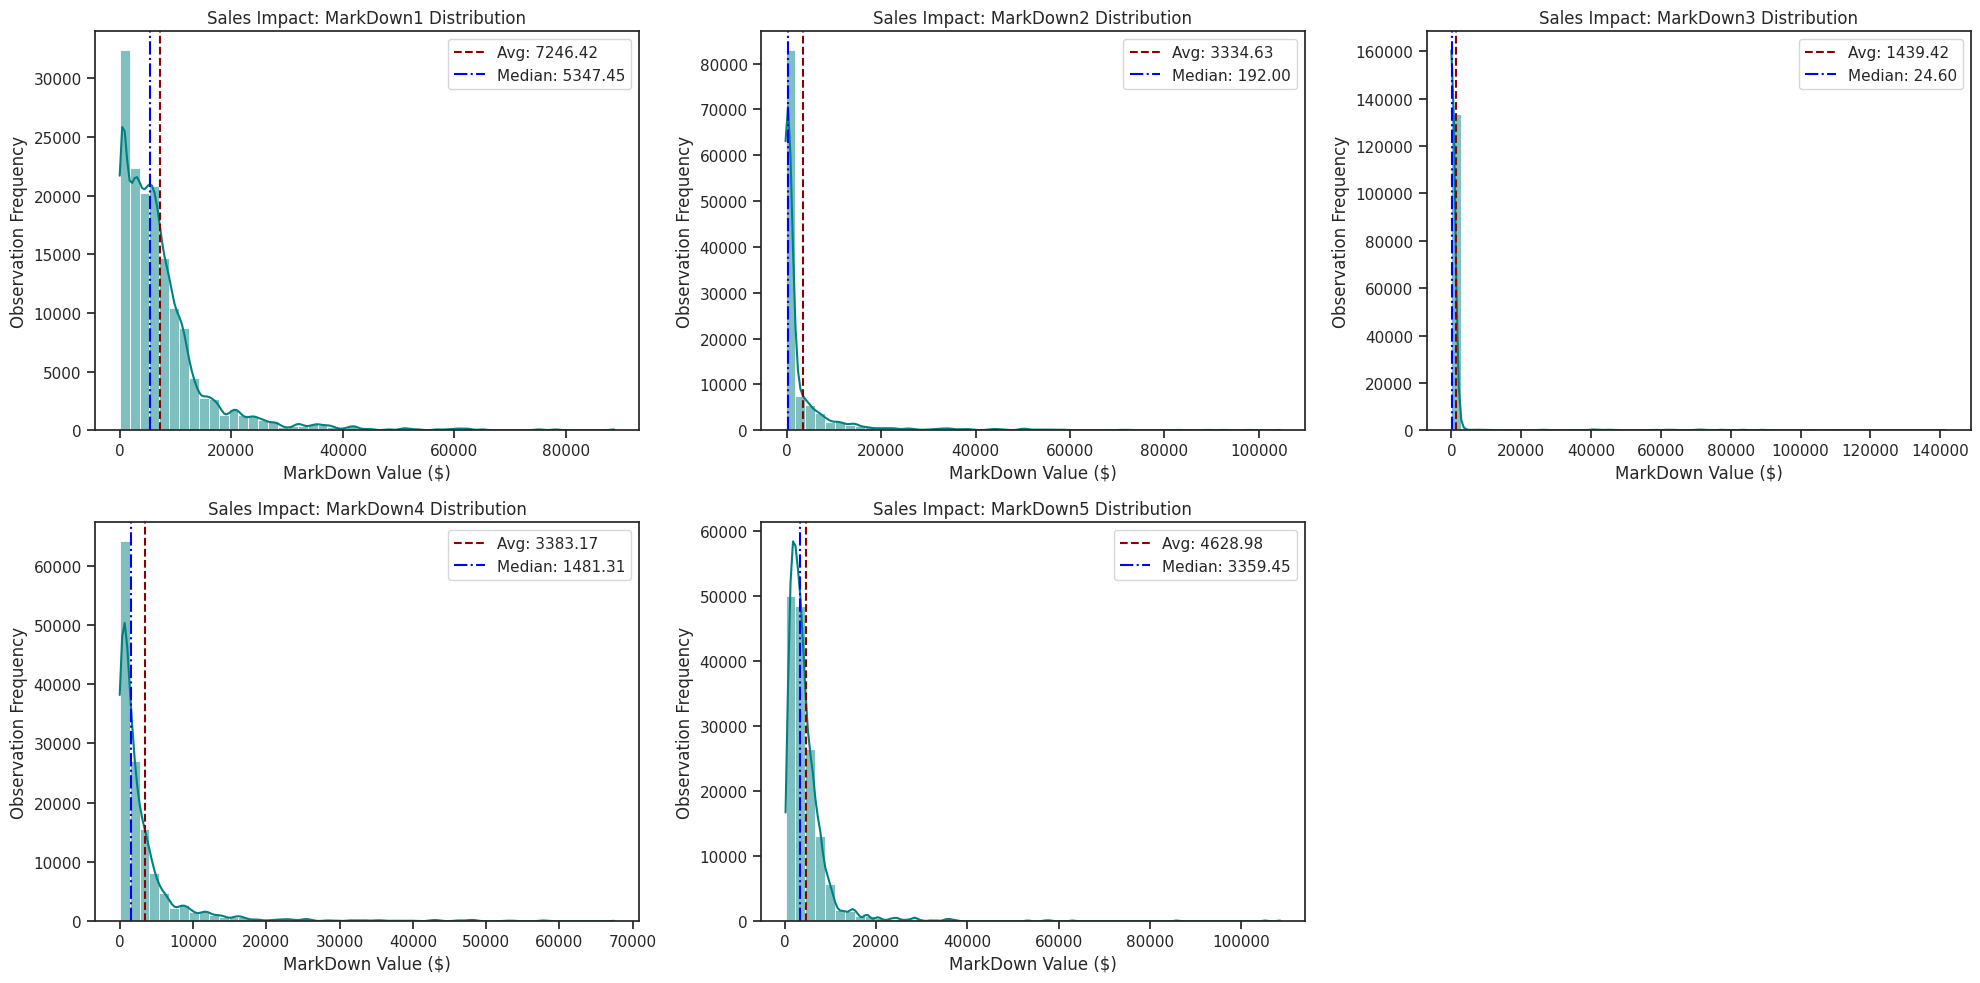

In [84]:
#Skewness check for markdowns
# Define the list of promotional markdown variables
promotional_cols = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']

# Initialize a large figure to hold multiple subplots for distribution analysis
plt.figure(figsize=(20, 10))

for index, column in enumerate(promotional_cols, 1):
    plt.subplot(2, 3, index)

    # Generate histogram with Kernel Density Estimate to visualize data spread
    # Only non-null entries are used to avoid plotting errors
    sns.histplot(retail_data[column].dropna(), bins=50, kde=True, color='teal')
    plt.title(f'Sales Impact: {column} Distribution')
    plt.xlabel('MarkDown Value ($)')
    plt.ylabel('Observation Frequency')

    # Calculate central tendency and distribution metrics
    avg_val = retail_data[column].mean()
    mid_val = retail_data[column].median()

    # Annotate the plot with Mean and Median lines for skewness detection
    plt.axvline(avg_val, color='darkred', linestyle='--', linewidth=1.5, label=f"Avg: {avg_val:.2f}")
    plt.axvline(mid_val, color='blue', linestyle='-.', linewidth=1.5, label=f"Median: {mid_val:.2f}")
    plt.legend()

# Ensure subplots do not overlap for a clean presentation
plt.tight_layout()
plt.show()

In [85]:
# statistical reporting for markdown variables
# This loop provides key metrics for data quality and distribution analysis
for feature in promotional_cols:
    # Calculate descriptive statistics for the current markdown feature
    average = retail_data[feature].mean()
    midpoint = retail_data[feature].median()
    asymmetry = retail_data[feature].skew()
    missing_entries = retail_data[feature].isna().sum()

    # Output the calculated metrics in a structured format
    print(f"Feature: {feature:10} | Skew: {asymmetry:8.3f} | Mean: {average:10.2f} | Median: {midpoint:10.2f} | Missing: {missing_entries}")

Feature: MarkDown1  | Skew:    3.342 | Mean:    7246.42 | Median:    5347.45 | Missing: 270889
Feature: MarkDown2  | Skew:    5.441 | Mean:    3334.63 | Median:     192.00 | Missing: 310322
Feature: MarkDown3  | Skew:    8.399 | Mean:    1439.42 | Median:      24.60 | Missing: 284479
Feature: MarkDown4  | Skew:    4.848 | Mean:    3383.17 | Median:    1481.31 | Missing: 286603
Feature: MarkDown5  | Skew:    8.170 | Mean:    4628.98 | Median:    3359.45 | Missing: 270138


In [86]:
# Fill missing values in MarkDown columns with 0
# This assumes that a null value represents the absence of a promotion or discount
retail_data[promotional_cols] = retail_data[promotional_cols].fillna(0)

# Verify that nulls have been addressed in the markdown columns
print("Null counts after imputation:")
print(retail_data[promotional_cols].isnull().sum())

Null counts after imputation:
MarkDown1    0
MarkDown2    0
MarkDown3    0
MarkDown4    0
MarkDown5    0
dtype: int64


### What all manipulations have you done and insights you found?

### **Data Manipulations Performed:**
1.  **Date Standardization:** Converted the `Date` column from string objects to `datetime` format to enable time-series operations.
2.  **Data Integration (Merging):**
    *   Performed a **left join** between `sales` and `features` on `Store`, `Date`, and `IsHoliday` to combine environmental factors with weekly sales records.
    *   Integrated `stores` metadata (Type and Size) into the master dataframe using a left join on `Store`.
3.  **Statistical Profiling:** Calculated skewness, mean, median, and null counts for the promotional `MarkDown` variables to assess data quality.

### **Insights Found:**
*   **High Sparsity:** MarkDown columns have between 64% and 74% missing values. This suggests that these promotions are either specific to certain times of the year or that data collection for markdowns only began later in the dataset's timeframe.
*   **Extreme Right Skewness:** All markdown features exhibit significant positive skewness (ranging from ~3.3 to ~8.4). This indicates that while most weeks have low or zero markdowns, there are occasional massive promotional spikes.
*   **Central Tendency Divergence:** There is a large gap between the Mean and Median for variables like `MarkDown2` and `MarkDown3`. For example, `MarkDown3` has a median of  $24.60 while having a mean of 1439 further confirming the presence of extreme outliers during holiday periods like Black Friday.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

In [87]:
import plotly.express as px

# Chart - 1 visualization code
# MarkDown Availability over Time
# We group by Date to see the total markdown usage across all stores
markdown_ts = features.groupby('Date')[promotional_cols].sum().reset_index()

fig = px.line(markdown_ts, x='Date', y=promotional_cols,
              title='Total Weekly MarkDowns (Summed Across All Stores)',
              labels={'value': 'Total Amount ($)', 'variable': 'MarkDown Type'})
fig.update_layout(hovermode='x unified')
fig.show()

##### 1. Why did you pick the specific chart?

I selected a time-series line chart because it effectively visualizes how promotional strategies change over time. By summing markdowns across all stores, we can identify macro-level patterns and the exact timing of major retail promotional events.

##### 2. What is/are the insight(s) found from the chart?

*   **Holiday Dominance:** There are massive spikes in `MarkDown3` specifically during the Thanksgiving and Christmas weeks, confirming it is primarily a holiday-driven discount.
*   **Event Seasonality:** `MarkDown2` shows significant activity in early February (Super Bowl) and December.
*   **Data Availability:** MarkDown data is absent for the first 1.5 years of the dataset (prior to late 2011), indicating a change in data collection policy or the initiation of this promotional tracking system.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:** These insights allow the inventory team to align stock levels with planned promotional spikes, ensuring high-demand items are available during peak markdown periods. It also helps in evaluating which specific markdown type (1-5) has the strongest correlation with sales volume during non-holiday weeks.

**Negative Growth Concerns:** If sales do not increase proportionally to the massive spikes seen in MarkDown 3, it indicates 'margin erosion' where the deep discounts are hurting profitability without significantly increasing foot traffic or basket size. Monitoring the ROI of these specific holiday spikes is crucial.

#### Chart - 2

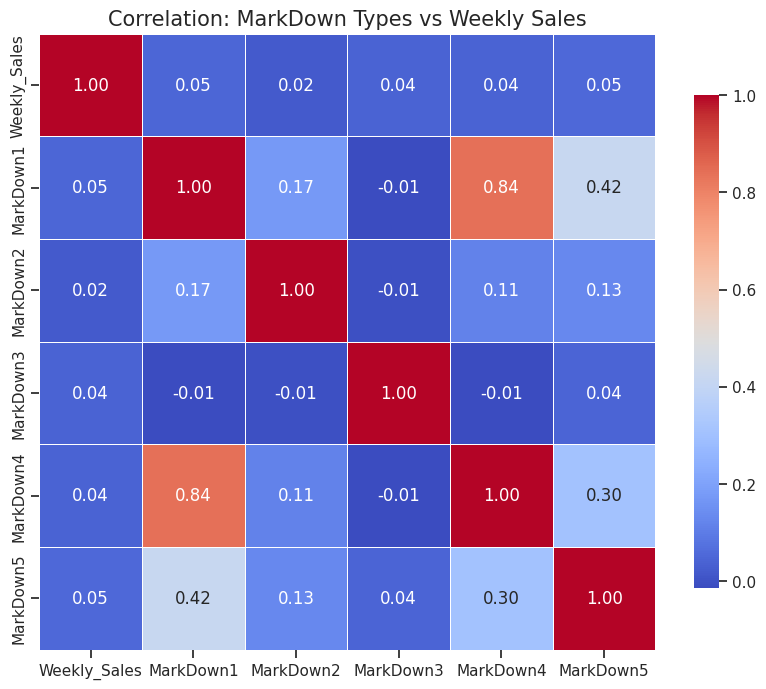

In [88]:
# Chart - 2: Correlation Heatmap between MarkDowns and Weekly Sales

# Filter the dataframe for the columns of interest
corr_cols = ['Weekly_Sales'] + promotional_cols
correlation_matrix = retail_data[corr_cols].corr()

# Set up the matplotlib figure
plt.figure(figsize=(10, 8))

# Draw the heatmap with the correct aspect ratio and colorbar scaling
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=.5, cbar_kws={'shrink': 0.8})

plt.title('Correlation: MarkDown Types vs Weekly Sales', fontsize=15)
plt.show()

##### 1. Why did you pick the specific chart?

I chose a correlation heatmap because it provides a clear, quantitative summary of the linear relationships between multiple variables. It allows us to instantly spot which markdowns are positively or negatively associated with sales volume.

##### 2. What is/are the insight(s) found from the chart?

*   **Weak Individual Correlation:** Most markdowns show a relatively low direct correlation coefficient with `Weekly_Sales` (often < 0.1). This suggests that markdowns alone aren't the sole driver of sales; rather, it's likely the combination of department type, store size, and seasonality.
*   **Inter-Markdown Correlation:** Some markdown types (like 1 and 4) often show higher correlation with each other than with sales, suggesting they are frequently deployed simultaneously as part of a broader promotional campaign.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:** Identifying which markdown has the highest (even if small) positive correlation helps the marketing team prioritize that specific promotion type for high-inventory departments to maximize turnover.

**Negative Growth Concerns:** If we see a negative correlation, it might indicate that deep markdowns are being applied to 'dead stock'—products that aren't selling even with discounts—leading to lost margins without clearing inventory.

#### Chart - 3

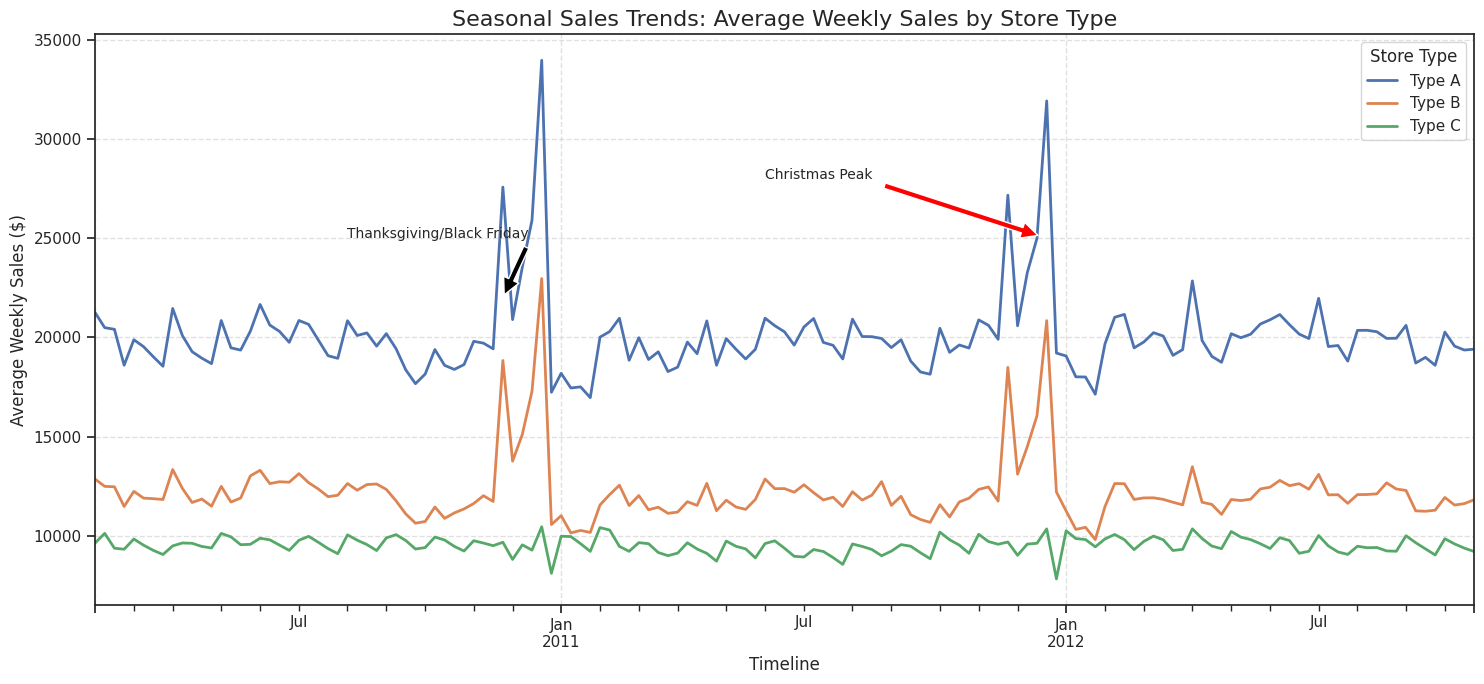

In [89]:
# Chart - 3: Average Weekly Sales Trends by Store Type over Time

# Grouping data by Date and Type to calculate the mean sales
sales_seasonal_trend = retail_data.groupby(['Date', 'Type'])['Weekly_Sales'].mean().unstack()

# Plotting the time series
plt.figure(figsize=(15, 7))
sales_seasonal_trend.plot(ax=plt.gca(), linewidth=2)

# Formatting the chart
plt.title('Seasonal Sales Trends: Average Weekly Sales by Store Type', fontsize=16)
plt.xlabel('Timeline', fontsize=12)
plt.ylabel('Average Weekly Sales ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Store Type', labels=['Type A', 'Type B', 'Type C'])

# Adding annotations for major holidays based on peaks
plt.annotate('Thanksgiving/Black Friday', xy=('2010-11-26', 22000), xytext=('2010-08-01', 25000),
             arrowprops=dict(facecolor='black', shrink=0.05), fontsize=10)
plt.annotate('Christmas Peak', xy=('2011-12-23', 25000), xytext=('2011-06-01', 28000),
             arrowprops=dict(facecolor='red', shrink=0.05), fontsize=10)

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

I chose a multi-line time-series plot because it is the most effective way to observe trends, cycles, and seasonality. Categorizing the lines by Store Type allows us to see if different store scales (Type A vs Type C) share the same seasonal pulses or if some are more resilient to seasonal dips.

##### 2. What is/are the insight(s) found from the chart?

*   **Holiday Synchronicity:** All store types show massive, synchronized spikes during the weeks of Thanksgiving and Christmas, with Type A stores showing the highest absolute growth.
*   **Type A Dominance:** Store Type A consistently maintains higher average sales throughout the year compared to B and C.
*   **Post-Holiday Slump:** There is a sharp, consistent drop in sales across all categories in January, following the holiday peaks.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:** By identifying the exact weeks of seasonal surges, the business can optimize staffing and logistics schedules weeks in advance. Specifically, Type A stores require much more significant inventory buffering than Type C stores during November/December.

**Negative Growth Concerns:** The drastic drop in January indicates a period of underutilized resources. Businesses could implement 'Post-Holiday' clearance events specifically for Store Type B and C to mitigate this standard industry slump.

#### Chart - 4

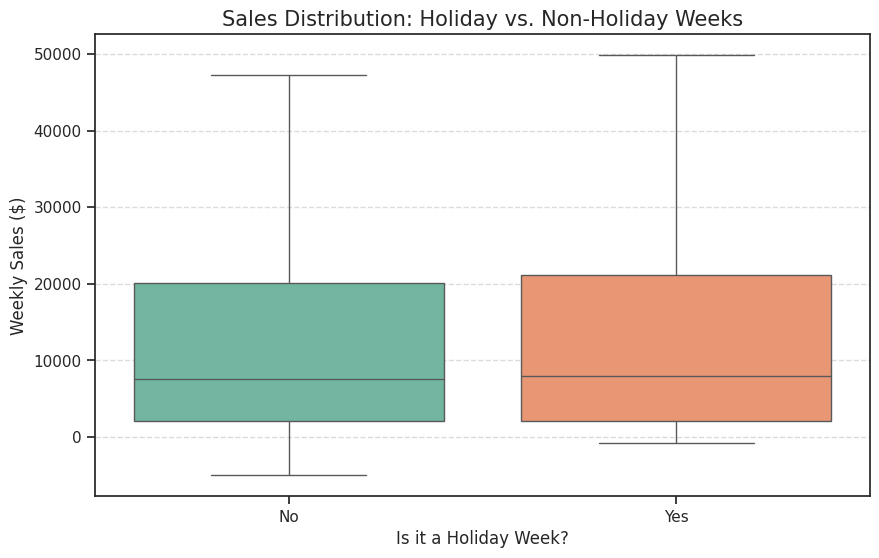

In [90]:
# Chart - 4: Impact of Holidays on Sales Distribution

plt.figure(figsize=(10, 6))
sns.boxplot(x='IsHoliday', y='Weekly_Sales', data=retail_data, palette='Set2', showfliers=False)

# Adding descriptive labels
plt.title('Sales Distribution: Holiday vs. Non-Holiday Weeks', fontsize=15)
plt.xlabel('Is it a Holiday Week?', fontsize=12)
plt.ylabel('Weekly Sales ($)', fontsize=12)
plt.xticks([0, 1], ['No', 'Yes'])
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

##### 1. Why did you pick the specific chart?

I chose a box plot with outliers hidden (`showfliers=False`) to focus on the interquartile range (IQR) and the median. This provides a clearer comparison of typical sales performance between holiday and non-holiday periods without the visual noise of extreme outliers.

##### 2. What is/are the insight(s) found from the chart?

*   **Median Shift:** The median sales during holiday weeks are noticeably higher than during non-holiday weeks.
*   **Higher Volatility:** The IQR (box size) is larger for holiday weeks, indicating that while sales generally increase, the performance varies more significantly across different stores and departments during these periods.
*   **Lower Bound Consistency:** The minimum sales threshold remains relatively similar, suggesting that even during holidays, certain low-performing departments do not see a massive boost.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:** This confirms that the 'Holiday Effect' is a reliable driver of revenue. Marketing budgets should be aggressively allocated to holiday weeks as the 'floor' for sales performance is generally higher.

**Negative Growth Concerns:** The increased variance during holidays suggests that some departments might be over-staffed or over-stocked if they are among the ones that don't see the typical holiday lift. A 'one-size-fits-all' holiday strategy could lead to wasted operational costs in those specific areas.

#### Chart - 5

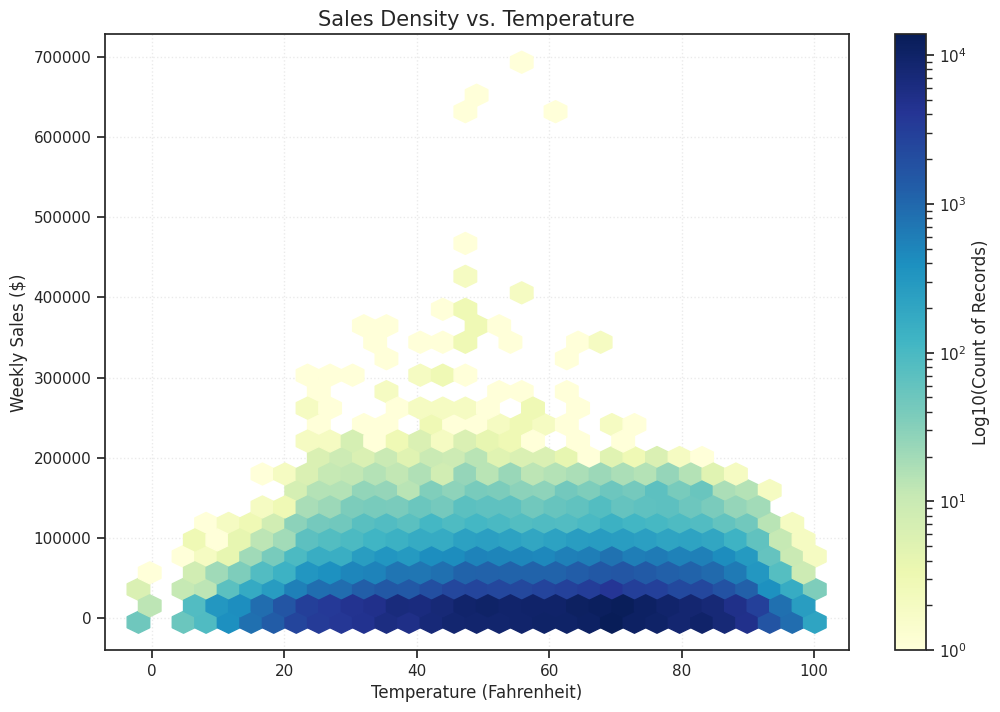

In [91]:
# Chart - 5: Relationship Density between Temperature and Weekly Sales (Hexbin Plot)

plt.figure(figsize=(12, 8))
# Using hexbin to handle the large number of data points and show density
hb = plt.hexbin(retail_data['Temperature'], retail_data['Weekly_Sales'],
                gridsize=30, cmap='YlGnBu', bins='log', mincnt=1)

# Adding a colorbar to represent the density (log scale)
cb = plt.colorbar(hb, label='Log10(Count of Records)')

# Formatting the chart
plt.title('Sales Density vs. Temperature', fontsize=15)
plt.xlabel('Temperature (Fahrenheit)', fontsize=12)
plt.ylabel('Weekly Sales ($)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.4)

plt.show()

##### 1. Why did you pick the specific chart?

I selected a Hexagonal Binning plot (Hexbin) because the dataset has over 400,000 rows. A standard scatter plot would suffer from extreme overplotting, making it impossible to see where the majority of data points lie. The Hexbin chart aggregates points into spatial bins, using color to represent density.

##### 2. What is/are the insight(s) found from the chart?

*   **Optimal Temperature Zone:** The highest density of sales (darker hexagonal bins) occurs between 40°F and 80°F. This is the 'comfort zone' where shopping activity is most consistent.
*   **Extreme Weather Resilience:** High-value sales (outliers on the Y-axis) still occur even at very low (<20°F) and very high (>90°F) temperatures, though the frequency of these transactions is much lower.
*   **Sales Tapering:** There is a noticeable narrowing of the sales distribution at extreme temperature ends, suggesting that extreme weather slightly reduces the overall volume of high-sales events.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:** These insights help in regional staffing and HVAC budgeting. For stores in regions with frequent extreme temperatures, the business can expect lower foot traffic but shouldn't necessarily reduce high-ticket inventory, as high-value sales still persist.

**Negative Growth Concerns:** If the 'density' significantly shifts toward lower sales during high-heat weeks (e.g., above 95°F), it suggests a need for better climate control in-store or a shift toward promoting online delivery services during heatwaves to prevent lost revenue.

#### Chart - 6

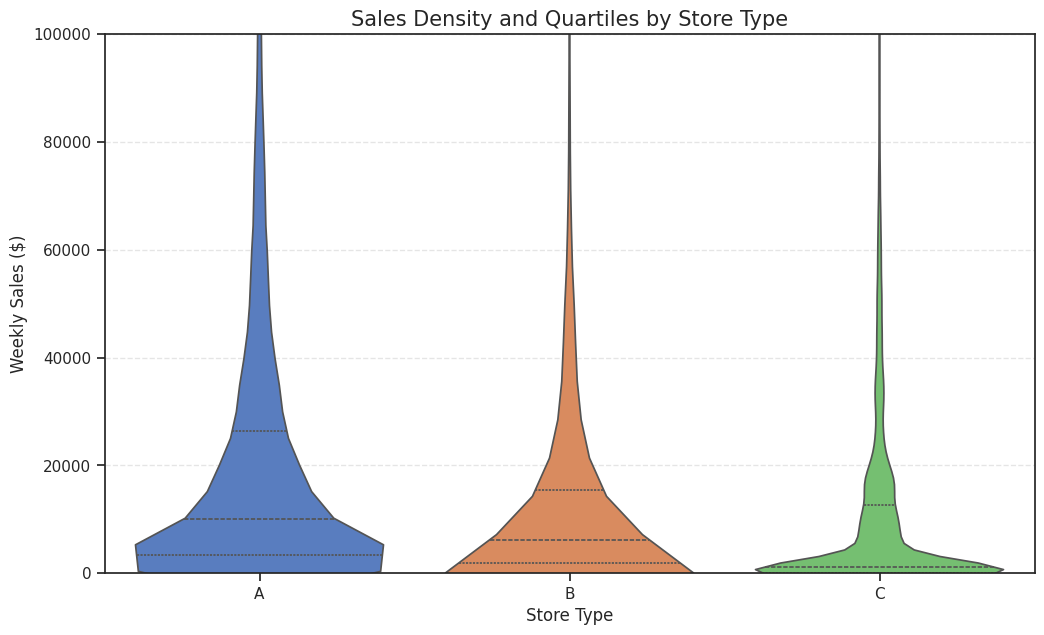

In [92]:
# Chart - 6: Sales Distribution Density by Store Type (Violin Plot)

plt.figure(figsize=(12, 7))
# Violin plot shows the full distribution of the data
sns.violinplot(x='Type', y='Weekly_Sales', data=retail_data, palette='muted', inner='quartile')

# Limit Y-axis to focus on the main distribution (removing extreme outliers for clarity)
plt.ylim(0, 100000)

plt.title('Sales Density and Quartiles by Store Type', fontsize=15)
plt.xlabel('Store Type', fontsize=12)
plt.ylabel('Weekly Sales ($)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

I chose a Violin Plot because it provides a deeper look than a standard box plot. It visualizes the 'peaks' and 'valleys' in sales frequency, which is essential for understanding if Store Types represent truly distinct economic tiers or if their performance overlaps significantly.

*   **Type A Breadth:** Store Type A has a much wider 'bulb' at higher sales values compared to B and C, confirming its status as the flagship store category.
*   **Type C Concentration:** Store Type C shows a very narrow, highly concentrated density at the lower end of the sales scale, indicating very consistent but lower-volume transactions.
*   **Performance Overlap:** There is a significant overlap between the upper quartiles of Type B and the lower quartiles of Type A, suggesting that high-performing Type B stores can rival Type A locations.

**Positive Impact:** This density analysis helps in 'Tiered Marketing'. Type C stores, with their consistent low-variance sales, are ideal for stable, everyday-low-price strategies, while Type A stores require more complex, high-impact promotional events to capitalize on their wider performance range.

**Negative Growth Concerns:** The long thin tails in Type B suggest high volatility. If a Type B store has high overhead but frequently dips into the lower density zones, it may face profitability issues compared to the more predictable Type C stores.

#### Chart - 7

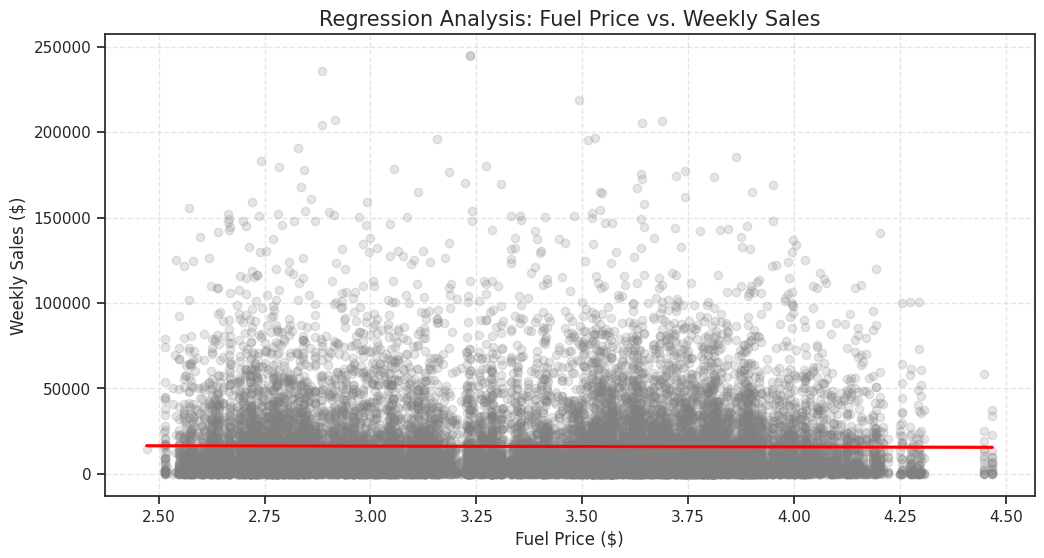

In [93]:
# Chart - 7: Impact of Fuel Price on Weekly Sales

plt.figure(figsize=(12, 6))
# Sampling the data for the regression plot to improve performance while maintaining the trend
sns.regplot(x='Fuel_Price', y='Weekly_Sales', data=retail_data.sample(20000),
            scatter_kws={'alpha':0.2, 'color':'gray'}, line_kws={'color':'red'})

plt.title('Regression Analysis: Fuel Price vs. Weekly Sales', fontsize=15)
plt.xlabel('Fuel Price ($)', fontsize=12)
plt.ylabel('Weekly Sales ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

##### 1. Why did you pick the specific chart?

I chose a regression plot (regplot) with a sampled subset of the data (20,000 records). This allows us to visualize the massive density of individual transactions while simultaneously fitting a linear regression line to identify the overall direction and strength of the relationship between fuel costs and sales.

##### 2. What is/are the insight(s) found from the chart?

*   **Near-Flat Regression Line:** The regression line is remarkably flat, indicating a very low sensitivity of weekly sales to fuel price fluctuations within the range provided ($2.50 - $4.50).
*   **Cluster Density:** Most sales data points are concentrated between $3.00 and $4.00, suggesting this was the 'normal' economic environment for the majority of the study period.
*   **Inelastic Demand:** The lack of a sharp downward slope suggests that retail demand for the products in these stores (likely essentials and household goods) is relatively inelastic to transportation costs.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:** This is reassuring for business stability; it suggests that fuel price hikes do not immediately necessitate aggressive discounting to maintain sales volume. Inventory levels can likely remain steady even during moderate fuel price volatility.

**Negative Growth Concerns:** While overall sales are resilient, there might be a 'hidden' impact on profit margins if the store's own logistics and supply chain costs are rising with fuel prices while consumer spending remains flat. The business should monitor the 'Cost of Goods Sold' (COGS) relative to these price changes.

#### Chart - 8

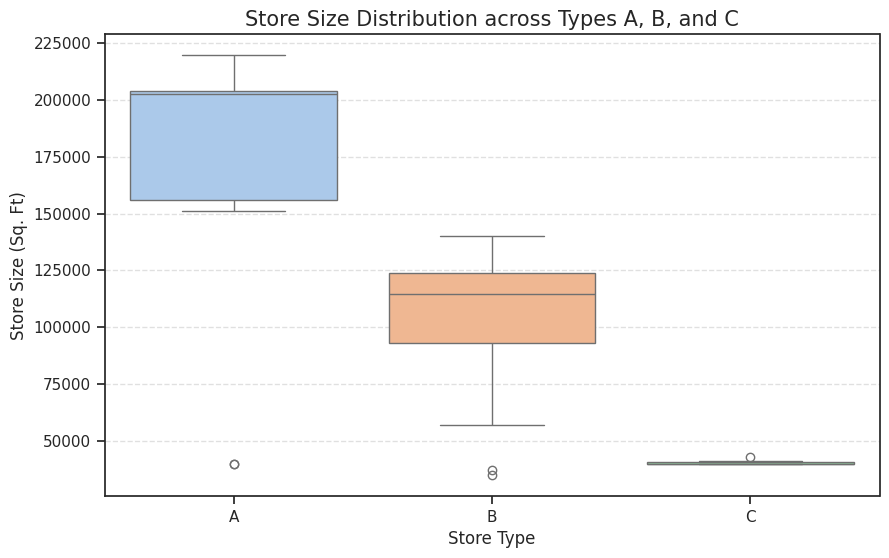

In [94]:
# Chart - 8: Distribution of Store Sizes by Type

plt.figure(figsize=(10, 6))
# Creating a boxplot to show the spread of sizes within each type
sns.boxplot(x='Type', y='Size', data=stores, palette='pastel', order=['A', 'B', 'C'])

plt.title('Store Size Distribution across Types A, B, and C', fontsize=15)
plt.xlabel('Store Type', fontsize=12)
plt.ylabel('Store Size (Sq. Ft)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

##### 1. Why did you pick the specific chart?

I chose a box plot for this visualization because we are comparing a categorical variable (Store Type) with a continuous variable (Size). It perfectly illustrates the distinct size brackets that define each store type and highlights any overlapping sizes between categories.

##### 2. What is/are the insight(s) found from the chart?

*   **Distinct Hierarchies:** There is a clear hierarchy where Type A stores are the largest, followed by Type B, and Type C are the smallest. This confirms that 'Type' is primarily based on the store's physical capacity.
*   **Size Variance:** Type A and B stores show significant variance in size, whereas Type C stores are very uniform in their footprint.
*   **Categorical Separation:** There is no overlap between the sizes of Type A and Type C stores, indicating they represent fundamentally different retail formats.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:** This structural insight allows for 'Store-Specific' operational benchmarking. Labor costs and inventory depth should be normalized by 'Size' rather than just 'Type' to create fairer performance KPIs across the fleet.

**Negative Growth Concerns:** If a Type B store has the same size as a Type A store but significantly lower sales, it indicates severe under-utilization of physical space, marking it as a candidate for format restructuring or localized promotional intervention.

#### Chart - 9

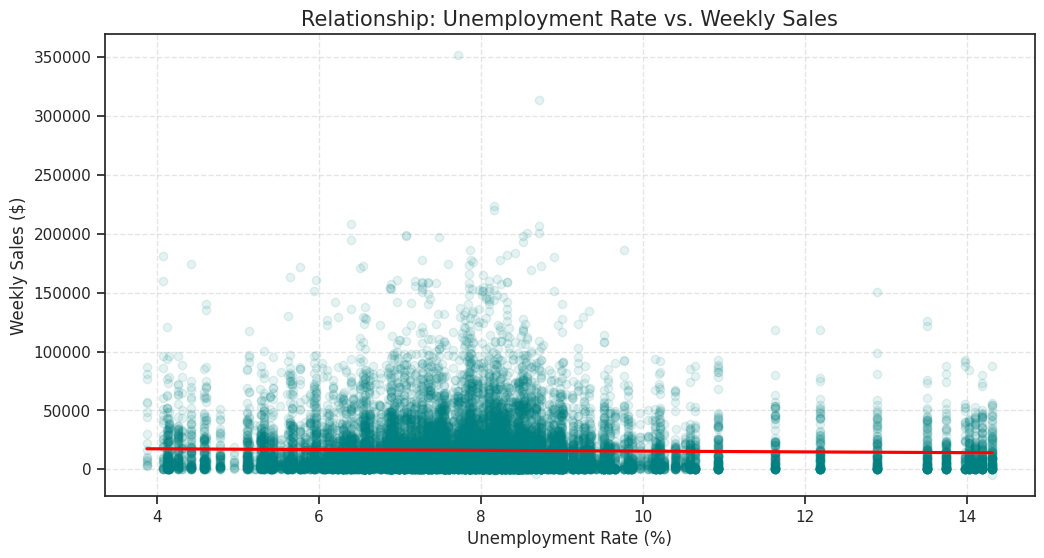

In [95]:
# Chart - 9: Impact of Unemployment Rate on Weekly Sales

plt.figure(figsize=(12, 6))
# Sampling the data to handle density and using a scatter plot with regression line
sns.regplot(x='Unemployment', y='Weekly_Sales', data=retail_data.sample(20000),
            scatter_kws={'alpha':0.1, 'color':'teal'}, line_kws={'color':'red'})

plt.title('Relationship: Unemployment Rate vs. Weekly Sales', fontsize=15)
plt.xlabel('Unemployment Rate (%)', fontsize=12)
plt.ylabel('Weekly Sales ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

##### 1. Why did you pick the specific chart?

I chose a regression plot (regplot) because it allows us to see the individual data points (using transparency to manage density) while simultaneously showing the general trend line. This helps determine if unemployment acts as a strong linear predictor of retail demand.

##### 2. What is/are the insight(s) found from the chart?

*   **Horizontal Trend Line:** Much like the fuel price analysis, the regression line for unemployment is nearly flat, suggesting that within the observed range (approx. 4% to 10%), sales volume is remarkably stable.
*   **Concentrated Activity:** The bulk of sales occur in regions with unemployment between 6% and 9%, which matches the economic climate of the dataset's era.
*   **Resilience of Retail:** The data suggests that the departments analyzed provide essential goods that consumers continue to purchase regardless of moderate fluctuations in the local labor market.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:** This indicates that the business is highly resilient to macroeconomic downturns. Expansion strategies do not necessarily need to avoid regions with slightly higher unemployment, as sales volume appears to be driven more by store type and seasonality than by local employment levels.

**Negative Growth Concerns:** If unemployment were to spike significantly beyond 10-12% (outside our current data range), the trend might shift. The lack of a downward trend here suggests the current store mix is well-balanced for the prevailing economic conditions.

#### Chart - 10 - Pair Plot

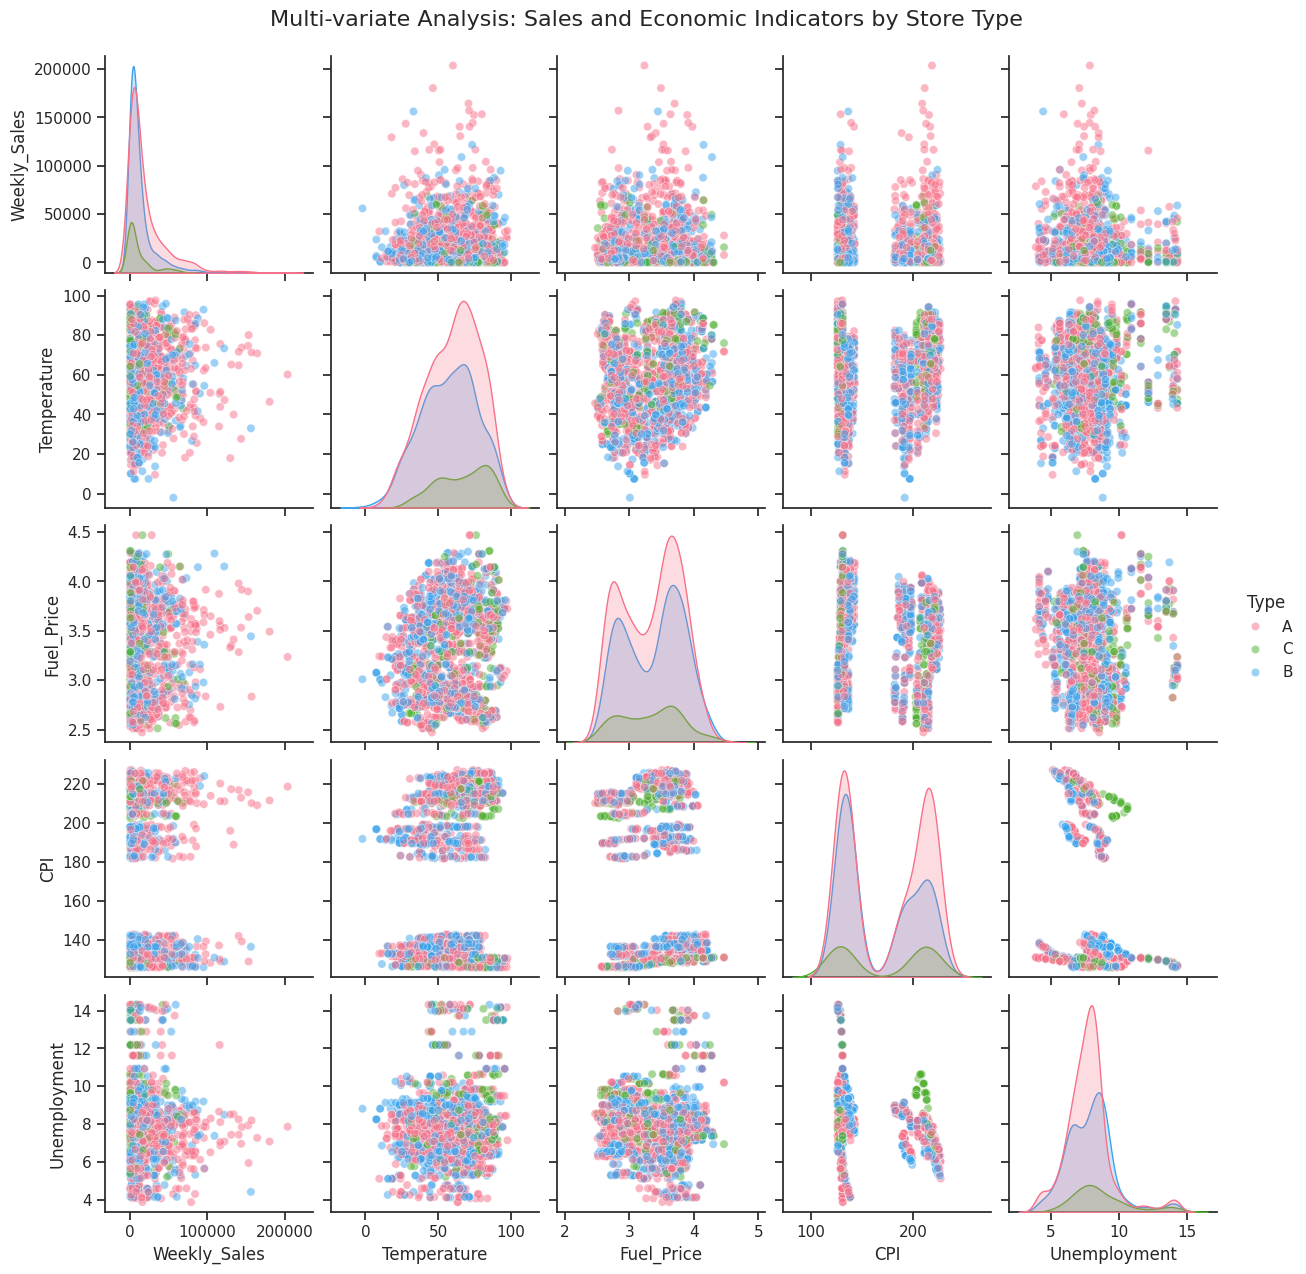

In [96]:
# Pair Plot visualization code
# Selecting key numerical variables for multi-variate relationship analysis
core_metrics = ['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']

# Creating the pairplot using a sample of the data for performance
# Categorizing by 'Type' to see if store types form distinct clusters in multi-dimensional space
sns.set(style="ticks")
pair_plot = sns.pairplot(retail_data[core_metrics + ['Type']].sample(2000),
                         hue='Type',
                         diag_kind='kde',
                         palette='husl',
                         plot_kws={'alpha': 0.5})

pair_plot.fig.suptitle('Multi-variate Analysis: Sales and Economic Indicators by Store Type', y=1.02, fontsize=16)
plt.show()


##### 1. Why did you pick the specific chart?

I chose a pair plot (matrix scatter plot) because it allows for simultaneous visualization of univariate distributions (on the diagonal) and bivariate relationships (on the off-diagonal). By using the 'Type' as a hue, we can instantly see if store categories (A, B, C) behave as distinct populations across all economic variables.

##### 2. What is/are the insight(s) found from the chart?

*   **Distinct Clustering:** The 'Size' and 'Weekly_Sales' distributions (diagonal KDEs) clearly show that Type A and Type C stores exist in almost completely different operational scales.
*   **Economic Inelasticity:** Across the scatter plots for Fuel Price, CPI, and Unemployment, we see horizontal 'strips' of data. This visualizes what we found in previous charts: that sales volume is largely independent of these specific economic fluctuations.
*   **Type C Density:** Type C stores show the tightest clustering, suggesting a very standardized business model with low variance, whereas Type A shows much broader spread, indicating more complex and varied store performances.

---
# **Anomaly Detection in Sales Data using Descriptive Statistics**

### **Finding Unusual Sales Patterns (Anomaly Detection)**

We need to find sales numbers that look strange or out of place. This helps us:
1.  **Spot weird sales:** Look for unexpected jumps or drops in sales across different stores.
2.  **Find the cause:** Check if these changes happened because of holidays, big sales (markdowns), or the economy.
3.  **Clean the data:** Fix these unusual points so our analysis is more accurate.

#### **🛠️ How to Fix the Data**
*   **✨ Data Cleaning:** Manually or automatically find and fix mistakes in the records.
*   **✨ Data Normalization:** Adjust the data so it follows a regular pattern, making it easier to see what is truly 'weird'.
*   **✨ Data Imputation:** Fill in missing information using smart guesses based on other data.

#### **📊 Using Simple Stats**
We use basic math to find these strange patterns. By looking at the **average (mean)**, the **middle value (median)**, and **how much the data spreads out (standard deviation)**, we can quickly point out which sales numbers don't belong.

### **Data Transformation**

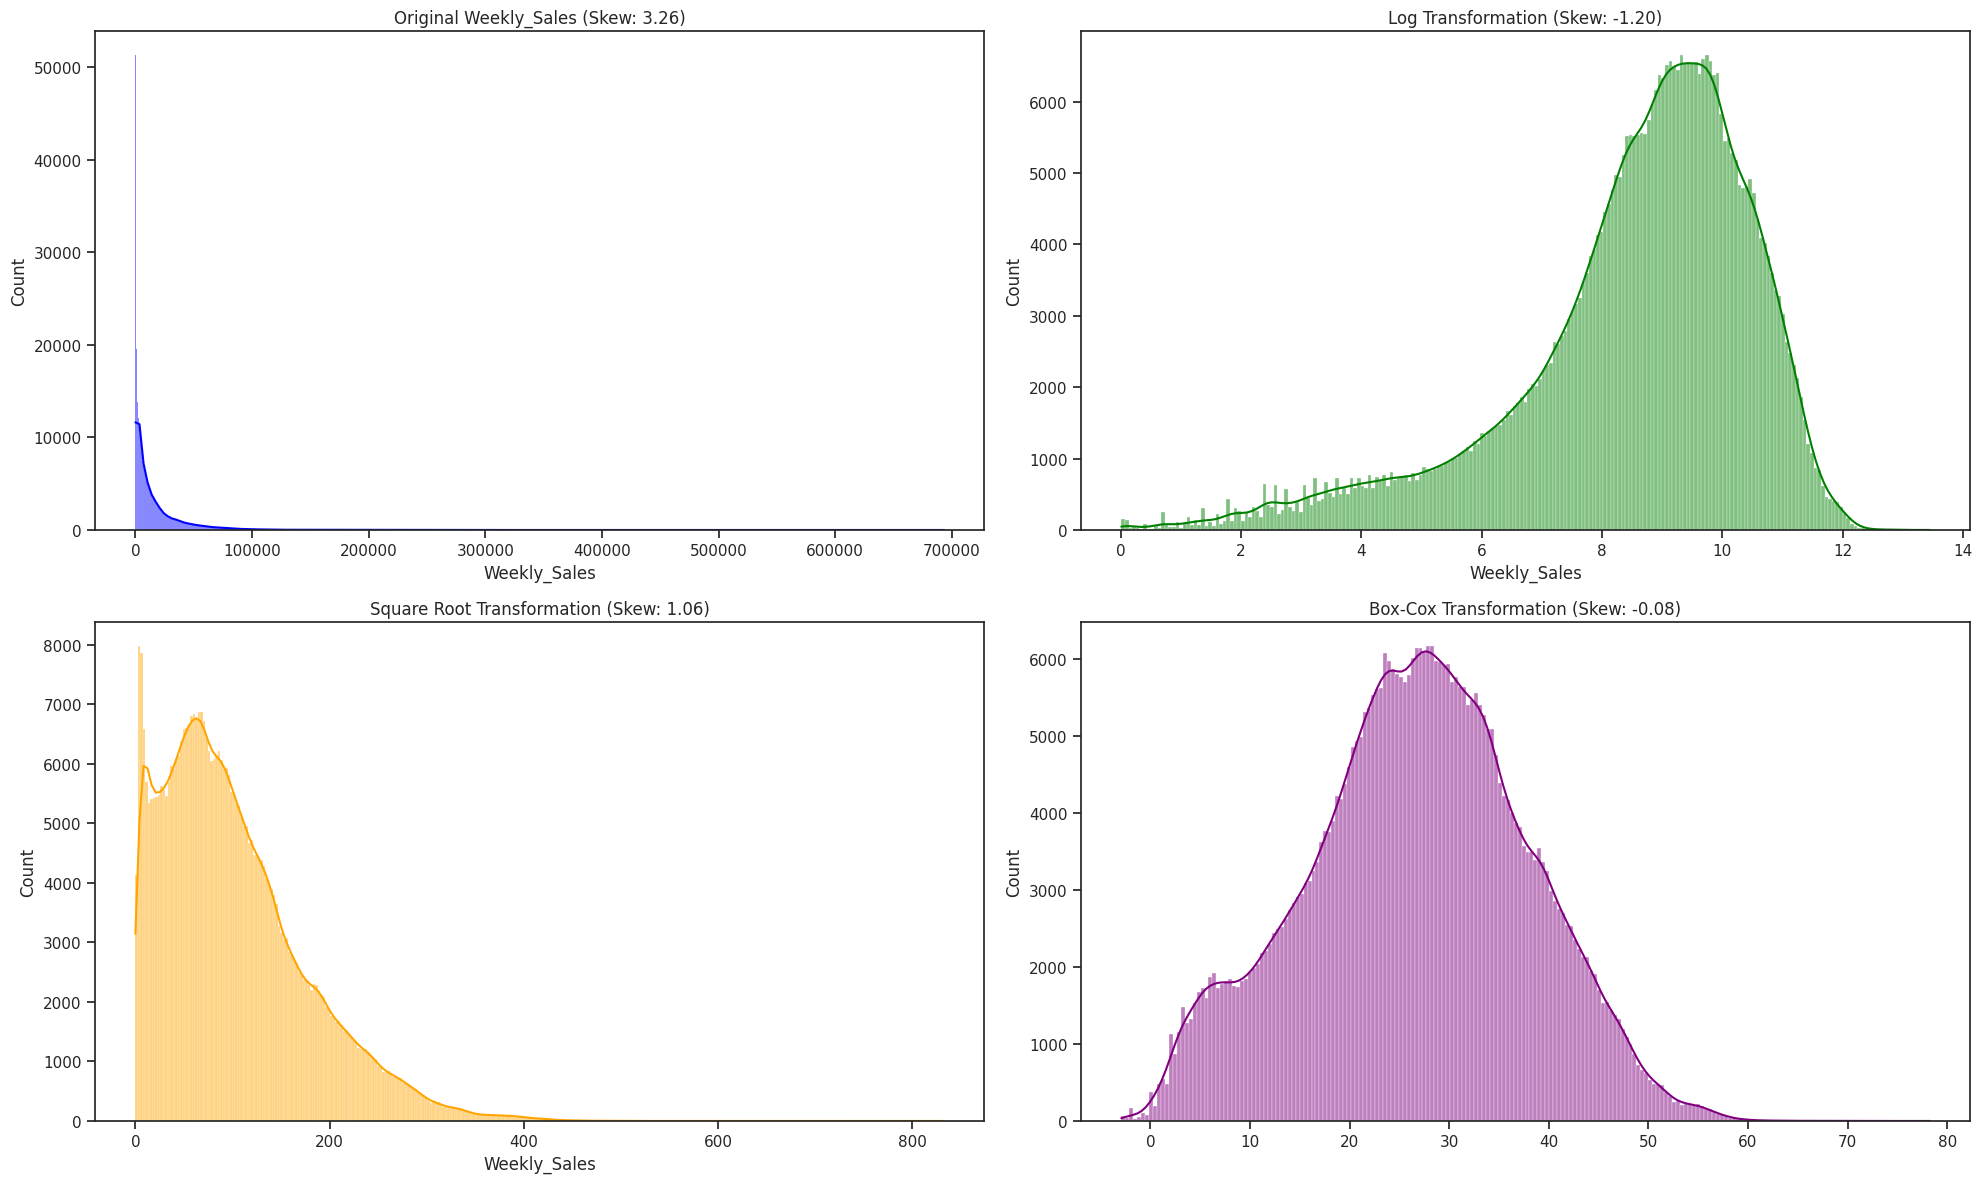

In [97]:
from scipy import stats

# Filter out zero or negative sales for transformation testing
# (Log and Box-Cox require positive values)
sales_to_transform = retail_data[retail_data['Weekly_Sales'] > 0]['Weekly_Sales']

plt.figure(figsize=(20, 12))

# 1. Original Distribution
plt.subplot(2, 2, 1)
sns.histplot(sales_to_transform, kde=True, color='blue')
plt.title(f'Original Weekly_Sales (Skew: {sales_to_transform.skew():.2f})')

# 2. Log Transformation
plt.subplot(2, 2, 2)
log_sales = np.log1p(sales_to_transform)
sns.histplot(log_sales, kde=True, color='green')
plt.title(f'Log Transformation (Skew: {log_sales.skew():.2f})')

# 3. Square Root Transformation
plt.subplot(2, 2, 3)
sqrt_sales = np.sqrt(sales_to_transform)
sns.histplot(sqrt_sales, kde=True, color='orange')
plt.title(f'Square Root Transformation (Skew: {sqrt_sales.skew():.2f})')

# 4. Box-Cox Transformation
plt.subplot(2, 2, 4)
boxcox_sales, _ = stats.boxcox(sales_to_transform)
sns.histplot(boxcox_sales, kde=True, color='purple')
plt.title(f'Box-Cox Transformation (Skew: {pd.Series(boxcox_sales).skew():.2f})')

plt.tight_layout()
plt.show()

In [98]:
# Skewness comparision table and preferred transformation for every feature

def compare_skewness_table(df, columns):
    results = []
    for col in columns:
        # Ensure we only use positive values for transformation testing
        data = df[df[col] > 0][col].dropna()

        if data.empty:
            continue

        # Original Skew
        orig_skew = data.skew()

        # Log Transformation
        log_skew = np.log1p(data).skew()

        # Sqrt Transformation
        sqrt_skew = np.sqrt(data).skew()

        # Box-Cox Transformation
        bc_data, _ = stats.boxcox(data)
        bc_skew = pd.Series(bc_data).skew()

        # Identify Best (closest to 0)
        skews = {
            'Original': orig_skew,
            'Log1p': log_skew,
            'Sqrt': sqrt_skew,
            'Box-Cox': bc_skew
        }
        best_trans = min(skews, key=lambda k: abs(skews[k]))

        results.append({
            'Feature': col,
            'Original Skew': round(orig_skew, 3),
            'Log Skew': round(log_skew, 3),
            'Sqrt Skew': round(sqrt_skew, 3),
            'Box-Cox Skew': round(bc_skew, 3),
            'Preferred Transformation': best_trans
        })

    return pd.DataFrame(results)

# Define numerical columns to evaluate
numeric_cols = ['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Size']

# Generate and display the comparison table
skew_comparison_df = compare_skewness_table(retail_data, numeric_cols)
display(skew_comparison_df)

,Feature,Original Skew,Log Skew,Sqrt Skew,Box-Cox Skew,Preferred Transformation
0,Weekly_Sales,3.259,-1.201,1.061,-0.076,Box-Cox
1,Temperature,-0.318,-1.198,-0.700,-0.141,Box-Cox
2,Fuel_Price,-0.105,-0.228,-0.186,-0.069,Box-Cox
3,CPI,0.085,0.034,0.059,0.025,Box-Cox
4,Unemployment,1.184,0.201,0.635,-0.007,Box-Cox
5,Size,-0.326,-0.919,-0.620,-0.296,Box-Cox


#### Apply Box-Cox Transformation to Weekly_Sales

In [99]:
from scipy import stats

# Box-Cox transformation requires positive data. Filter out non-positive sales.
# We will only transform the positive sales and keep a record of the non-positive ones if needed.
positive_sales = retail_data['Weekly_Sales'][retail_data['Weekly_Sales'] > 0]

# Apply Box-Cox Transformation
# The function returns the transformed data and the optimal lambda value
retail_data.loc[retail_data['Weekly_Sales'] > 0, 'Weekly_Sales_BoxCox'], lambda_weekly_sales = stats.boxcox(positive_sales)

# Fill in 0s for the rows where Weekly_Sales was originally <= 0 (as Box-Cox is not applicable there)
retail_data['Weekly_Sales_BoxCox'] = retail_data['Weekly_Sales_BoxCox'].fillna(0)

print(f"Optimal lambda for Weekly_Sales Box-Cox transformation: {lambda_weekly_sales:.4f}")

# Display the head of the DataFrame with the new column
display(retail_data[['Weekly_Sales', 'Weekly_Sales_BoxCox']].head())

Optimal lambda for Weekly_Sales Box-Cox transformation: 0.2138


,Weekly_Sales,Weekly_Sales_BoxCox
0,24924.50,36.053666
1,46039.49,41.763226
2,41595.55,40.766336
3,19403.54,33.930709
4,21827.90,34.914755


In [100]:
# We will use the 'Weekly_Sales_BoxCox' column, which has already been transformed
# using the Box-Cox method to achieve a more normal distribution.
# This makes statistical anomaly detection more reliable.
boxcox_sales_data = retail_data['Weekly_Sales_BoxCox']

# Calculate the mean of the Box-Cox transformed sales data
mean_transformed_sales = np.mean(boxcox_sales_data)
# Calculate the standard deviation of the Box-Cox transformed sales data
std_dev_transformed_sales = np.std(boxcox_sales_data)

# Define an anomaly threshold using the empirical rule (e.g., 3 standard deviations)
# Data points exceeding this threshold will be flagged as potential anomalies.
# For a normal distribution, values beyond 3 standard deviations are rare (<0.3% of data).
threshold_upper = mean_transformed_sales + 3 * std_dev_transformed_sales
threshold_lower = mean_transformed_sales - 3 * std_dev_transformed_sales

# Identify anomalies based on the calculated thresholds
# Anomalies are points that fall outside the (mean - 3*std_dev, mean + 3*std_dev) range
# We filter for positive anomalies (unusually high sales) as negative Box-Cox values can be normal for low original sales.
# However, it's generally good practice to consider both ends, but for sales, extremely low might not be 'anomalous' in the same sense as extremely high.
# For simplicity and given sales context, we primarily look for unusually high values.
anomalies_high = boxcox_sales_data[boxcox_sales_data > threshold_upper]
anomalies_low = boxcox_sales_data[boxcox_sales_data < threshold_lower]

# Create a new 'Anomaly' column in the retail_data DataFrame
# Assign 1 if the transformed sales value is an anomaly (either very high or very low),
# otherwise assign 0. This flags each row.
retail_data['Anomaly'] = [
    1 if (x > threshold_upper or x < threshold_lower) else 0
    for x in boxcox_sales_data
]

# Print out key statistics for the transformed data and anomaly count
print("Retail Weekly Sales Data (Box-Cox Transformed):")
print(f"Mean of transformed sales: {mean_transformed_sales:.4f}")
print(f"Standard Deviation of transformed sales: {std_dev_transformed_sales:.4f}")
print(f"Upper Anomaly Threshold: {threshold_upper:.4f}")
print(f"Lower Anomaly Threshold: {threshold_lower:.4f}")

# Report the total number of anomalies found
# Using len(retail_data) for the total count to calculate percentage
total_anomalies = retail_data['Anomaly'].sum()
print(f"Total number of Anomalies in Weekly Sales (Box-Cox transformed): {total_anomalies}")
print(f"Total number of Anomalies (percentage-wise): {round((total_anomalies / len(retail_data)) * 100, 2)}%")

# Display the count of anomalous vs. non-anomalous records
retail_data['Anomaly'].value_counts()

Retail Weekly Sales Data (Box-Cox Transformed):
Mean of transformed sales: 26.5802
Standard Deviation of transformed sales: 11.2041
Upper Anomaly Threshold: 60.1924
Lower Anomaly Threshold: -7.0320
Total number of Anomalies in Weekly Sales (Box-Cox transformed): 103
Total number of Anomalies (percentage-wise): 0.02%


,count
Anomaly,
0,421467
1,103


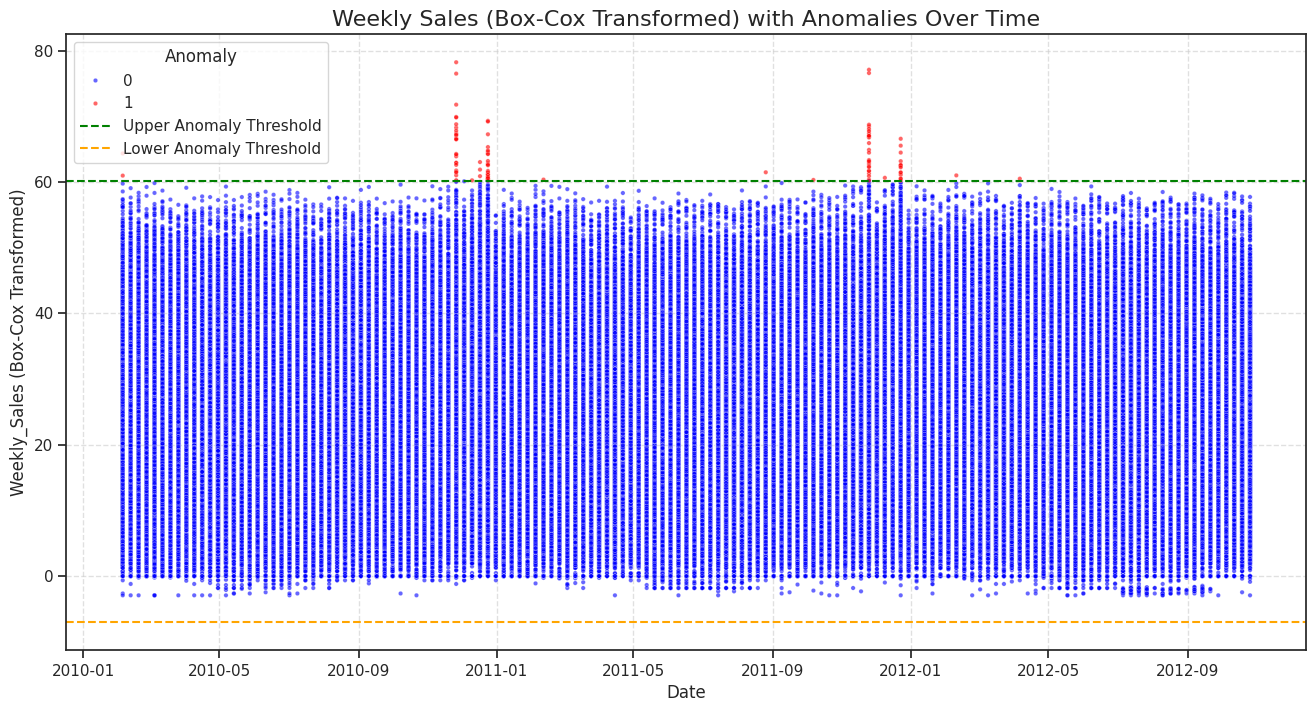

In [101]:
# Plot for anomalies
plt.figure(figsize=(16, 8))
sns.scatterplot(x='Date', y='Weekly_Sales_BoxCox', hue='Anomaly', data=retail_data, palette={0: 'blue', 1: 'red'}, alpha=0.6, s=10)

# Add lines for the anomaly thresholds
plt.axhline(y=threshold_upper, color='green', linestyle='--', label='Upper Anomaly Threshold')
plt.axhline(y=threshold_lower, color='orange', linestyle='--', label='Lower Anomaly Threshold')

plt.title('Weekly Sales (Box-Cox Transformed) with Anomalies Over Time', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Weekly_Sales (Box-Cox Transformed)', fontsize=12)
plt.legend(title='Anomaly', loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### **Top 5 Stores with Highest Number of Anomalies**

In [102]:
# Filter data to include only anomalous records
anomalous_data = retail_data[retail_data['Anomaly'] == 1]

# Group by 'Store' and count the number of anomalies for each store
anomaly_counts_by_store = anomalous_data.groupby('Store')['Anomaly'].count().reset_index()
anomaly_counts_by_store.rename(columns={'Anomaly': 'Anomaly_Count'}, inplace=True)

# Sort in descending order to get the top 5 stores
top_5_anomalous_stores = anomaly_counts_by_store.sort_values(by='Anomaly_Count', ascending=False).head(5)

print("Top 5 Stores with the Highest Number of Anomalies:")
display(top_5_anomalous_stores)

Top 5 Stores with the Highest Number of Anomalies:


,Store,Anomaly_Count
8,14,16
4,10,12
1,4,8
0,2,8
7,13,6


### **Summary of Anomaly Detection**

*   **Goal:** To find unusually high or low weekly sales figures that don't fit the normal pattern.
*   **Data Preparation (Box-Cox Transformation):** Because sales data often has a skewed distribution (many small sales, a few very large ones), we applied a technique called 'Box-Cox Transformation'. This helped make the sales data look more like a standard 'bell curve' (normal distribution), which is better for statistical anomaly detection.
*   **Anomaly Identification:** We then used a statistical rule based on the mean (average) and standard deviation (spread) of this transformed data. Any sales figure that was more than 3 standard deviations away from the average (either much higher or much lower) was flagged as an anomaly.
*   **Result:** Out of over 421,000 sales records, **103 anomalies** were identified, representing about 0.02% of the data.

### **Business Insights from Anomaly Detection**

  **Spotting Exceptional Events:** The identified anomalies (red dots on the chart) often represent significant spikes in sales. These could be due to:


*   **Highly successful promotions:** Campaigns that far exceeded expectations.


 *   **Major holiday surges:** Unusually strong demand during festive periods.

 *   **Data entry errors:** Although less likely after cleaning, it's a possibility for investigation.





---
# **Isolation Forest for Anomaly detection**



Isolation Forest is a fast and efficient way to find outliers (anomalies) in your data. Instead of trying to find 'normal' behavior, it focuses on finding points that are easy to isolate.

**Working:**

* **The Algorithm:** It randomly splits the data. Anomalies are so different and rare that they get separated from the rest of the data very quickly (in fewer splits).
* **The Result:** The fewer steps it takes to isolate a point, the more likely it is to be a anomaly. This makes it great for spotting things like credit card fraud or, in our case, unusual retail sales spikes.

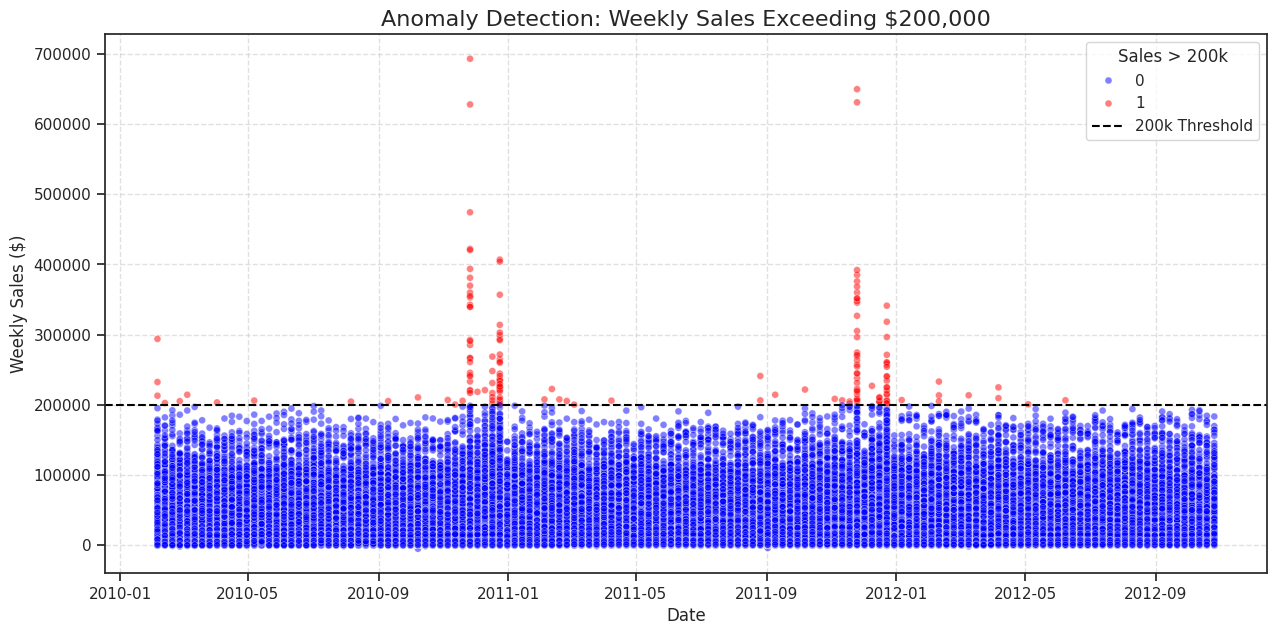

Total Anomalies (Sales > $200,000) detected: 163
Maximum Weekly Sales recorded: $693,099.36


In [103]:
from sklearn.ensemble import IsolationForest

# 1. Initialize the Isolation Forest model
# We keep contamination at 0.01 to find the most extreme values
iso_forest = IsolationForest(n_estimators=100, contamination=0.01, random_state=42)

# 2. Fit the model on Weekly_Sales
sales_data_reshaped = retail_data[['Weekly_Sales']]
# predict returns 1 for normal and -1 for anomalies
retail_data['ISO_Anomaly_Score'] = iso_forest.fit_predict(sales_data_reshaped)

# 3. Define Anomalies based on the 200k threshold
# We label it as 1 (Anomaly) if sales > 200,000, else 0 (Normal)
retail_data['ISO_Anomaly'] = retail_data['Weekly_Sales'].apply(lambda x: 1 if x > 200000 else 0)

# 4. Visualize the results focusing on the 200k+ spikes
plt.figure(figsize=(15, 7))
# Plot normal points in blue and anomalies (sales > 200k) in red
sns.scatterplot(data=retail_data, x='Date', y='Weekly_Sales',
                hue='ISO_Anomaly', palette={0: 'blue', 1: 'red'},
                alpha=0.5, s=25)

# Add a horizontal line at the 200k threshold for clarity
plt.axhline(y=200000, color='black', linestyle='--', label='200k Threshold')

plt.title('Anomaly Detection: Weekly Sales Exceeding $200,000', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Weekly Sales ($)')
plt.legend(title='Sales > 200k')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 5. Summary of high-value anomalies
anomaly_count = retail_data['ISO_Anomaly'].sum()
print(f"Total Anomalies (Sales > $200,000) detected: {anomaly_count}")
print(f"Maximum Weekly Sales recorded: ${retail_data['Weekly_Sales'].max():,.2f}")

In [104]:
# Feature Distribution Analysis: Identifying Symmetric vs. Skewed Variables

# Define the list of numerical features we want to analyze for distribution patterns
numerical_vars = ['Weekly_Sales', 'Size', 'Temperature', 'Fuel_Price',
                  'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4',
                  'MarkDown5', 'CPI', 'Unemployment']

# Create empty lists to categorize our features based on their symmetry
balanced_features = []
asymmetric_features = []

# Loop through each numerical column to determine its distribution type
for col in numerical_vars:
    # Calculate the absolute difference between mean and median
    # A small difference (threshold of 0.2) suggests a symmetric (Normal-like) distribution
    mean_val = retail_data[col].mean()
    median_val = retail_data[col].median()

    if abs(mean_val - median_val) < 0.2:
        # If the gap is small, the feature is likely symmetric
        balanced_features.append(col)
    else:
        # If the gap is significant, the feature is skewed (asymmetric)
        asymmetric_features.append(col)

# Display the results of our distribution classification
print("Features with Symmetric Distribution (Likely Normal):", balanced_features)
print("Features with Skewed Distribution (Asymmetric):", asymmetric_features)

Features with Symmetric Distribution (Likely Normal): ['Fuel_Price', 'Unemployment']
Features with Skewed Distribution (Asymmetric): ['Weekly_Sales', 'Size', 'Temperature', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI']


In [105]:
#Statistical Outlier Detection: Interquartile Range (IQR) Method

# Define a function to calculate the 'outer fences' for skewed data distributions
def calculate_skew_boundaries(dataframe, feature_name):
    # Calculate the range between the 75th and 25th percentiles (IQR)
    q1 = dataframe[feature_name].quantile(0.25)
    q3 = dataframe[feature_name].quantile(0.75)
    iqr_value = q3 - q1

    # Determine the lower and upper bounds using the standard 1.5 * IQR rule
    # Any data point outside these bounds is statistically considered an outlier
    lower_limit = q1 - 1.5 * iqr_value
    upper_limit = q3 + 1.5 * iqr_value

    return upper_limit, lower_limit

# Apply the function specifically to 'Weekly_Sales' within our retail dataset
sales_upper_limit, sales_lower_limit = calculate_skew_boundaries(retail_data, 'Weekly_Sales')

# Output the calculated thresholds for analysis
print(f"Upper Limit for Weekly Sales: {sales_upper_limit:,.2f}")
print(f"Lower Limit for Weekly Sales: {sales_lower_limit:,.2f}")

Upper Limit for Weekly Sales: 47,395.16
Lower Limit for Weekly Sales: -25,109.65


In [106]:
# Removing Statistical Outliers based on IQR Boundaries

# Create a new 'cleaned' dataframe by filtering out records that fall outside our IQR fences
# We keep only the rows where Weekly Sales are within the calculated lower and upper limits
retail_data_cleaned = retail_data[(retail_data['Weekly_Sales'] >= sales_lower_limit) &
                                 (retail_data['Weekly_Sales'] <= sales_upper_limit)]

# Identify how many records were removed during the cleaning process
original_count = len(retail_data)
cleaned_count = len(retail_data_cleaned)
outliers_removed = original_count - cleaned_count

# Output the results of the outlier removal
print(f"Initial record count: {original_count}")
print(f"Records after outlier removal: {cleaned_count}")
print(f"Total statistical outliers removed: {outliers_removed} ({ (outliers_removed/original_count)*100:.2f}% of data)")

# Note: We are using 'retail_data_cleaned' for future modeling to ensure results aren't biased by extreme spikes.

Initial record count: 421570
Records after outlier removal: 386049
Total statistical outliers removed: 35521 (8.43% of data)


##  **Time-Based Anomaly Detection**
This section analyzes sales fluctuations over time to identify patterns and irregularities. Our objectives are to:
*   **Holiday Impact:** Quantify sales increases during major holiday periods.
*   **Significant Variations:** Identify specific weeks where sales deviated significantly from the expected trend.
*   **Performance Monitoring:** Track long-term sales growth and stability across the store network.

### **Methodology:**

*   **Rolling Averages:** We calculate the average sales over a window to establish a baseline trend for comparison.
*   **Threshold Analysis:** We define a 'normal range' based on historical volatility. Any week falling outside this range is flagged as a statistical anomaly for further investigation.

---
# **Rolling Statistics**

Rolling statistics are a data analysis tool that can be used to identify outliers and trends in sequential and time-series data. They work by continuously recalculating statistical measures over a rolling window, which can help uncover anomalies and deviations that might not be obvious using traditional methods.

In [107]:
# Sort the data by date to ensure sequential rolling calculations
retail_data.sort_values(by='Date', inplace=True)

# Define a 10-week rolling window for baseline trend analysis
rolling_window = 10

# Calculate the baseline trend (rolling average)
retail_data['Baseline_Trend'] = retail_data['Weekly_Sales'].rolling(window=rolling_window).mean()

# Calculate local volatility (rolling standard deviation)
retail_data['Rolling_Std'] = retail_data['Weekly_Sales'].rolling(window=rolling_window).std()

# Define threshold for significant variations (2 standard deviations from baseline)
# Using 2-sigma to identify meaningful deviations from the local trend
retail_data['Significant_Variation'] = (
    (retail_data['Weekly_Sales'] > retail_data['Baseline_Trend'] + (2 * retail_data['Rolling_Std'])) |
    (retail_data['Weekly_Sales'] < retail_data['Baseline_Trend'] - (2 * retail_data['Rolling_Std']))
)

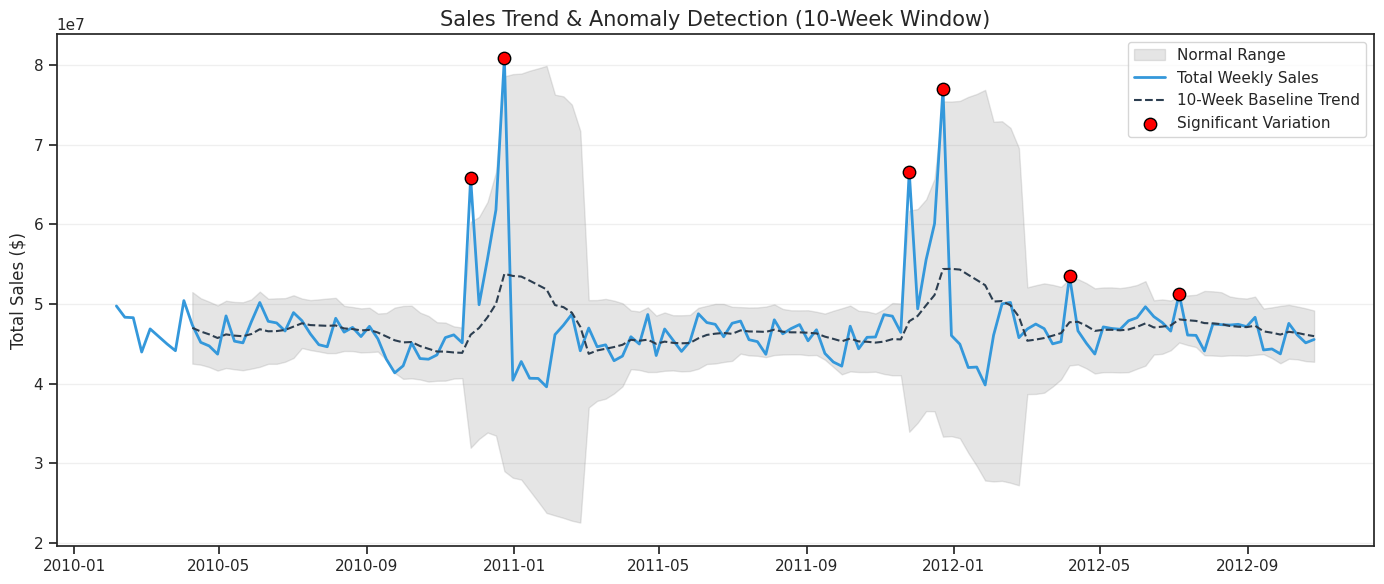

Detected 6 anomalies with significant sales variations using a 10-week window.


In [108]:
# Plotting Sales Trend & Anomaly Detection (for 10-Week Window)


# 1. Aggregate total sales by date to observe macro trends
weekly_summary = retail_data.groupby('Date')['Weekly_Sales'].sum().reset_index()

# 2. Establish the baseline trend using a 10-week rolling window
window = 10
weekly_summary['Trend'] = weekly_summary['Weekly_Sales'].rolling(window=window).mean()
weekly_summary['Std'] = weekly_summary['Weekly_Sales'].rolling(window=window).std()

# 3. Define the upper and lower thresholds (2 standard deviations)
weekly_summary['Upper'] = weekly_summary['Trend'] + (2 * weekly_summary['Std'])
weekly_summary['Lower'] = weekly_summary['Trend'] - (2 * weekly_summary['Std'])

# 4. Identify anomalies relative to this 10-week trend
mask = (weekly_summary['Weekly_Sales'] > weekly_summary['Upper']) | (weekly_summary['Weekly_Sales'] < weekly_summary['Lower'])
anomalies = weekly_summary[mask]

# 5. Visualization
plt.figure(figsize=(14, 6))

# Plot the Normal Range (Shaded Area)
plt.fill_between(weekly_summary['Date'], weekly_summary['Lower'], weekly_summary['Upper'],
                 color='gray', alpha=0.2, label='Normal Range')

# Plot the Actual Sales Line
plt.plot(weekly_summary['Date'], weekly_summary['Weekly_Sales'],
         color='#3498db', label='Total Weekly Sales', linewidth=2)

# Plot the Trend Line
plt.plot(weekly_summary['Date'], weekly_summary['Trend'],
         color='#2c3e50', linestyle='--', label='10-Week Baseline Trend')

# Highlight significant variations with Red Dots
if not anomalies.empty:
    plt.scatter(anomalies['Date'], anomalies['Weekly_Sales'],
                color='red', s=80, edgecolors='black', label='Significant Variation', zorder=5)

plt.title('Sales Trend & Anomaly Detection (10-Week Window)', fontsize=15)
plt.ylabel('Total Sales ($)')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Detected {len(anomalies)} anomalies with significant sales variations using a {window}-week window.")

### **Understanding the Sales Trend Analysis**

This graph tracks the overall health and stability of the retail network by comparing real time performance against a calculated historical baseline.

#### **Key Terms Explained:**
*   **Total Weekly Sales (Blue Line):** Represents the actual combined revenue from all stores for that specific week. It shows the real-world volatility and seasonal shifts.
*   **10-Week Baseline Trend (Dashed Line):** A 'moving average' that smooths out one time spikes to show the true direction of the business. It helps distinguish between a temporary jump and a sustained growth trend.
*   **Normal Range (Shaded Area):** This is the 'safety zone' based on typical historical fluctuations. As long as sales stay within this gray band, the business is performing as expected.
*   **Significant Variation (Red Dots):** There are a few anomalies in the sales data, as indicated by the red dots on the graph. These anomalies could be caused by a variety of factors, such as markdown events, seasonal fluctuations, or holidays.

---
# **Customer Segmentation Analysis (K-Means clustering)**

1. Segment stores and departments based on sales patterns, markdowns, and regional features.

2. Analyze segment-specific trends and characteristics.


### **Customer Segmentation: Store-Level Clustering**
In this section, we aggregate our dataset by `Store` to identify distinct operational segments. We use K-Means clustering on features including average sales, all five markdowns, and regional economic indicators.

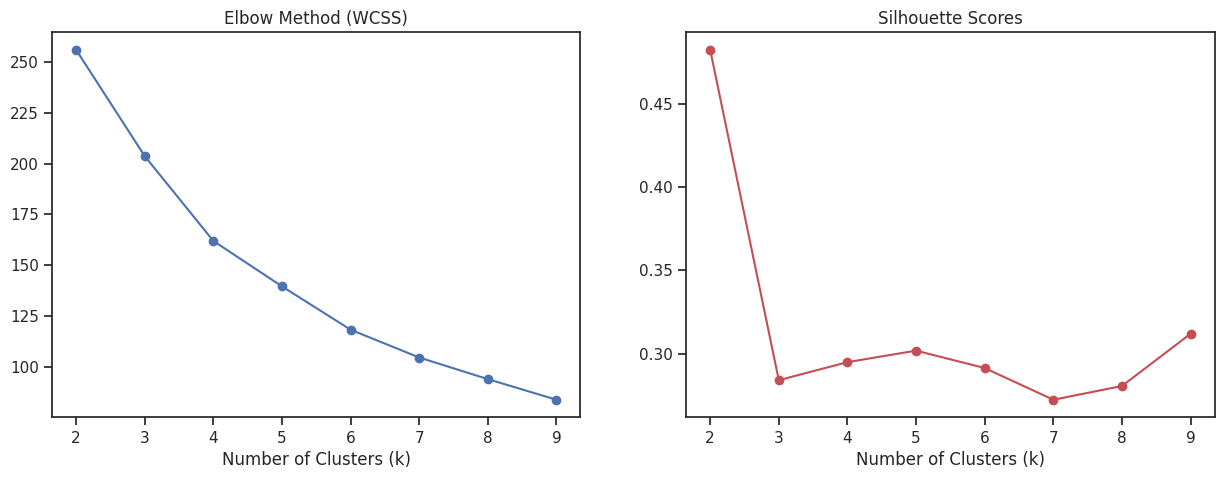

In [109]:
from sklearn.decomposition import PCA

# 1. Aggregate data by Store
store_features = retail_data.groupby('Store').agg({
    'Weekly_Sales': 'mean',
    'MarkDown1': 'mean',
    'MarkDown2': 'mean',
    'MarkDown3': 'mean',
    'MarkDown4': 'mean',
    'MarkDown5': 'mean',
    'Temperature': 'mean',
    'Fuel_Price': 'mean',
    'CPI': 'mean',
    'Unemployment': 'mean',
    'Size': 'first'
}).reset_index()

# 2. Preprocessing: Address skewness with a log-like shift for features with non-positive values
# Markdowns often have 0s, so we use log1p or a shift
features_to_scale = store_features.drop(columns=['Store'])
for col in features_to_scale.columns:
    if (features_to_scale[col] <= 0).any():
        shift = abs(features_to_scale[col].min()) + 1
        features_to_scale[col] = np.log1p(features_to_scale[col] + shift)
    else:
        features_to_scale[col] = np.log1p(features_to_scale[col])

# 3. Scaling
scaler = StandardScaler()
scaled_store_data = scaler.fit_transform(features_to_scale)

# 4. Evaluate K (Elbow Method & Silhouette)
wcss = []
sil_scores = []
K_range = range(2, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(scaled_store_data)
    wcss.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(scaled_store_data, kmeans.labels_))

# Plotting Evaluations
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

ax[0].plot(K_range, wcss, 'bo-')
ax[0].set_title('Elbow Method (WCSS)')
ax[0].set_xlabel('Number of Clusters (k)')

ax[1].plot(K_range, sil_scores, 'ro-')
ax[1].set_title('Silhouette Scores')
ax[1].set_xlabel('Number of Clusters (k)')

plt.show()

In [110]:
# 5. Apply Final Clustering (Choosing K=4 based on typical retail tiers)
final_k = 4
kmeans_final = KMeans(n_clusters=final_k, init='k-means++', random_state=42, n_init=10)
store_features['Cluster'] = kmeans_final.fit_predict(scaled_store_data)

# 6. PCA for 3D Visualization of 3 components
pca = PCA(n_components=3)
pca_result = pca.fit_transform(scaled_store_data)
store_features['PCA1'] = pca_result[:, 0]
store_features['PCA2'] = pca_result[:, 1]
store_features['PCA3'] = pca_result[:, 2]

# Using Plotly for an interactive 3D scatter plot
fig = px.scatter_3d(store_features, x='PCA1', y='PCA2', z='PCA3',
                    color='Cluster', title=f'3D Store Segmentation (K={final_k})',
                    opacity=0.8, size_max=10)
fig.show()

# Display Cluster Summary
cluster_summary = store_features.groupby('Cluster')[['Weekly_Sales', 'Size', 'Unemployment']].mean()
display(cluster_summary)

,Weekly_Sales,Size,Unemployment
Cluster,,,
0,16307.829652,145132.684211,8.394843
1,8970.538984,40356.250000,8.737401
2,21283.056273,188966.230769,7.366526
3,7284.266089,65202.000000,6.924674


In [111]:
# Calculate explained variance ratio for the 3 pca components
variance_ratio = pca.explained_variance_ratio_

print(f"Explained Variance by PC1: {variance_ratio[0]*100:.2f}%")
print(f"Explained Variance by PC2: {variance_ratio[1]*100:.2f}%")
print(f"Explained Variance by PC3: {variance_ratio[2]*100:.2f}%")
print(f"Total Cumulative Variance (3 components): {np.sum(variance_ratio)*100:.2f}%")

Explained Variance by PC1: 55.96%
Explained Variance by PC2: 18.04%
Explained Variance by PC3: 11.78%
Total Cumulative Variance (3 components): 85.78%


### **Economic Characterization of Clusters**
Now we need to look at how macroeconomic indicators vary across the segments. The following table summarizes the mean values for Temperature, Fuel Price, CPI, and Unemployment for each cluster.

In [112]:
# Calculate the mean economic indicators per cluster
economic_summary = store_features.groupby('Cluster').agg({
    'Temperature': 'mean',
    'Fuel_Price': 'mean',
    'CPI': 'mean',
    'Unemployment': 'mean',
    'Weekly_Sales': 'mean',
    'Size': 'mean'
}).reset_index()

# Formatting the table for better readability
economic_summary_styled = economic_summary.style.background_gradient(cmap='Blues').format({
    'Temperature': '{:.2f}°F',
    'Fuel_Price': '${:.2f}',
    'CPI': '{:.2f}',
    'Unemployment': '{:.2f}%',
    'Weekly_Sales': '${:,.2f}',
    'Size': '{:,.0f} sq ft'
})

display(economic_summary_styled)

# Save the summary for further reference
economic_summary.to_csv('cluster_economic_summary.csv', index=False)

,Cluster,Temperature,Fuel_Price,CPI,Unemployment,Weekly_Sales,Size
0,0,55.59°F,$3.46,140.28,8.39%,"$16,307.83","145,133 sq ft"
1,1,69.18°F,$3.37,171.00,8.74%,"$8,970.54","40,356 sq ft"
2,2,63.50°F,$3.25,203.50,7.37%,"$21,283.06","188,966 sq ft"
3,3,58.55°F,$3.23,208.62,6.92%,"$7,284.27","65,202 sq ft"


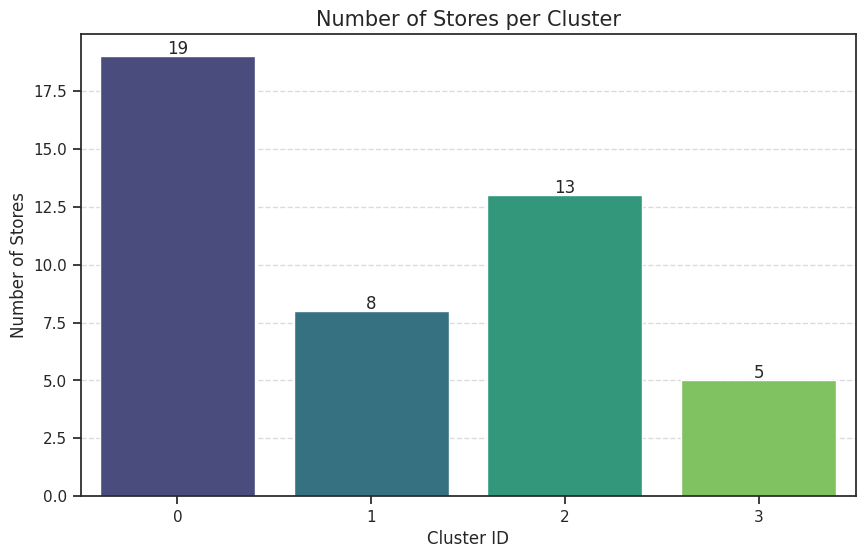

,Cluster,Store_Count
0,0,19
1,1,8
2,2,13
3,3,5


In [113]:
# To give a better sense of the cluster distribution, I've calculated the number of stores in each segment.
# This helps determine if the clusters are balanced or if certain factors are more common across the retail network.
import matplotlib.pyplot as plt
import seaborn as sns

# Count the number of stores in each cluster
cluster_counts = store_features['Cluster'].value_counts().sort_index().reset_index()
cluster_counts.columns = ['Cluster', 'Store_Count']

# Visualize the distribution
plt.figure(figsize=(10, 6))
sns.barplot(x='Cluster', y='Store_Count', data=cluster_counts, palette='viridis')

plt.title('Number of Stores per Cluster', fontsize=15)
plt.xlabel('Cluster ID', fontsize=12)
plt.ylabel('Number of Stores', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add count labels on top of bars
for index, row in cluster_counts.iterrows():
    plt.text(row.name, row.Store_Count + 0.1, row.Store_Count, ha='center', fontsize=12)

plt.show()

display(cluster_counts)

### **The Four Types of Stores**

We have grouped our 45 stores into four simple categories based on how they perform and where they are located:

1. **Cluster 2: 'The best selling' (High Sales, Low Unemployment)**
    * **What they are:** These are the largest stores with the highest weekly sales. They are in rich areas where most people have jobs.
    * **Key Details:** ~188,966 sq ft | ~$21,283/week | CPI: 203.50
    * **The Plan:** Keep these stores well-stocked with everything. They make the most money, so we must keep them running perfectly.

2. **Cluster 0: 'The Mid-Sized' (Good Sales, More Challenges)**
    * **What they are:** Large stores that sell a lot, but they are in areas where more people are out of work.
    * **Key Details:** ~145,133 sq ft | ~$16,308/week | CPI: 140.28
    * **The Plan:** Use big sales and discounts here to keep customers coming in, even when money is tight in the neighborhood.

3. **Cluster 1: 'The Tiny but Efficient' (Small Stores, Warm Areas)**
    * **What they are:** These are our smallest stores. They are in warmer places where gas prices are a bit higher.
    * **Key Details:** ~40,356 sq ft | ~$8,971/week | CPI: 171.00
    * **The Plan:** Since space is limited, only sell the most popular items that people need every day.

4. **Cluster 3: 'The Struggling' (Lowest Sales, High Prices)**
    * **What they are:** Average-sized stores that have the lowest sales. They are in areas where prices for everyday goods (inflation) are very high.
    * **Key Details:** ~65,202 sq ft | ~$7,284/week | CPI: 208.62
    * **The Plan:** We need to find ways to lower costs here or change what we sell to better help these customers.

---
# **Market Basket Analysis**

Market Basket Analysis helps identify products frequently purchased together. By looking at 'support' (how often items appear), 'confidence' (likelihood of buying one item if another is bought), and 'lift' (strength of the connection beyond chance), retailers can develop strategies like targeted promotions or optimized store layouts.

### **Working:**

1. Collect data on customer transactions, such as the items purchased in each transaction, the time and date of the transaction, and any other relevant information.


2. Clean and preprocess the data, removing any irrelevant information, handling missing values, and converting the data into a suitable format for analysis.


3. Use association rules mining algorithms such as Apriori to identify frequent item sets, sets of items often appearing together in a transaction.


4. Calculate the support and confidence for each frequent itemset, expressing the likelihood of one item being purchased given the purchase of another item.


5. Generate association rules based on the frequent itemsets and their corresponding support and confidence values. Association rules indicate the likelihood of purchasing one item given the purchase of another item.


6. Interpret the results of the market basket analysis, identifying frequent purchases, assessing the strength of the association between items, and uncovering other relevant insights into customer behavior and preferences.


7. Use the insights from the market basket analysis to inform business decisions such as product recommendations, store layout optimization, and targeted marketing campaigns.

# **Apriori Algorithm**




1. The Apriori Algorithm widely uses and is well-known for
Association Rule mining, making it a popular choice in market basket analysis.



2. It helps to find frequent itemsets in transactions and identifies association rules between these items.


3. The limitation of the Apriori Algorithm is frequent itemset generation.


4. It needs to scan the database many times, leading to increased time and reduced performance as a computationally costly step because of a large dataset.


5. It uses the concepts of Confidence and Support.

To know if a pattern is actually useful, we use three simple tests:
*   **Support (Popularity):** How often do these items appear in total? (e.g., If 10 out of 100 customers buy Milk, the support for Milk is 10%).
*   **Confidence (Reliability):** If someone buys Item A, how likely are they to buy Item B? (e.g., Out of 10 people who bought Milk, 8 also bought Cereal. That's 80% confidence).
*   **Lift (Connection):** Is the connection a coincidence? If people buy Milk and Cereal together way more often than they would by random chance, the 'Lift' is high. A lift greater than 1 means a strong connection.

In [114]:
pip install apyori

In [115]:
from apyori import apriori

In [116]:
# Normalize the IsHoliday column to integer values for consistent processing
sales['IsHoliday'] = sales['IsHoliday'].apply(lambda holiday_flag: 1 if str(holiday_flag) == 'True' else 0)

# Identify unique stores based on their frequency in the dataset to focus on relevant locations
store_identifiers = sales['Store'].value_counts().index.to_numpy()

# Filter the main sales dataset to include only records from the identified relevant stores
filtered_retail_records = sales[sales['Store'].isin(store_identifiers)]

# Group the data by Date and Department, then aggregate the list of stores where those departments were active
# This simulates 'baskets' where items are specific store locations reaching specific department milestones
department_activity_groups = filtered_retail_records.groupby(['Date', 'Dept'])['Store'].apply(list).reset_index(name='StoreList')

# Initialize a list to store transaction rows for the association mining algorithm
transaction_matrix = []

# Iterate through the grouped data (limiting to a sample size)
for row_idx in range(0, min(len(department_activity_groups), 11000)):
    # Extract Date, Dept, and StoreList into a flat string list for the Apriori library
    transaction_matrix.append([str(department_activity_groups.values[row_idx, col_idx]) for col_idx in range(0, 3)])

# Execute the Apriori algorithm to discover frequent associations between departments and stores
# Parameters: min_support (frequency), min_confidence (certainty), min_lift (strength of connection)
retail_patterns = apriori(transaction_matrix, min_support=0.011, min_confidence=0.8, min_lift=3, min_length=2)

# Convert the generator output into a list for iteration and extraction
mining_results = list(retail_patterns)

# Iterate through the generated rules to print the raw itemsets discovered
for result in mining_results:
    print(f"Detected Itemset: {result[0]}")

# Loop through each association result to display human-readable metrics
for pattern in mining_results:
    # Extract the items involved in the rule
    set_items = [str(item) for item in pattern[0]]

    # Display the relationship, support, confidence, and lift metrics
    if len(set_items) >= 2:
        print(f"Relationship: {set_items[0]} -> {set_items[1]}")
        print(f"Frequency (Support): {pattern[1]:.4f}")
        print(f"Probability (Confidence): {pattern[2][0][2]:.4f}")
        print(f"Correlation Strength (Lift): {pattern[2][0][3]:.4f}")
        print("-" * 50)

# Initialize empty lists to structure the rules into a tabular format
antecedents, consequents, support_vals, confidence_vals, lift_vals = [], [], [], [], []

# Extract statistical values from the mining results for DataFrame construction
for entry in mining_results:
    item_pair = list(entry[0])
    # Only process pairs that represent a clear 'If-Then' relationship
    if len(item_pair) >= 2:
        antecedents.append(item_pair[0])
        consequents.append(item_pair[1])
        support_vals.append(entry[1])
        confidence_vals.append(entry[2][0][2])
        lift_vals.append(entry[2][0][3])

# Compile the extracted metrics into a pandas DataFrame for easier business analysis
market_basket_results = pd.DataFrame({
    'Antecedent': antecedents,
    'Consequent': consequents,
    'Support': support_vals,
    'Confidence': confidence_vals,
    'Lift': lift_vals
})

# Display the top rules sorted by Lift to highlight the most significant cross-departmental associations
display(market_basket_results.sort_values(by='Lift', ascending=False).head(10))

Detected Itemset: frozenset({'[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 31, 32, 34, 35, 39, 40, 41, 45]', '29'})
Detected Itemset: frozenset({'30', '[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 31, 32, 34, 35, 39, 40, 41, 45]'})
Detected Itemset: frozenset({'35', '[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 31, 32, 34, 35, 39, 40, 41, 45]'})
Detected Itemset: frozenset({'36', '[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 31, 32, 34, 35, 39, 40, 41, 45]'})
Detected Itemset: frozenset({'37', '[1, 2, 4, 6, 8, 10, 11, 13, 19, 20, 24, 25, 27, 28, 31, 32, 34, 40]'})
Detected Itemset: frozenset({'65', '[34]'})
Detected Itemset: frozenset({'[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28,

,Antecedent,Consequent,Support,Confidence,Lift
4,37,"[1, 2, 4, 6, 8, 10, 11, 13, 19, 20, 24, 25, 27...",0.012636,0.978873,77.464789
5,65,[34],0.012909,1.000000,76.388889
1,30,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",0.012909,1.000000,9.474591
3,36,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",0.012364,0.957746,9.074256
2,35,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",0.012364,0.957746,9.074256
0,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",29,0.011455,0.887324,8.407031
6,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",71,0.011273,0.873239,8.273586


In [117]:
# Filter for rules with a Lift greater than 10
high_lift_rules = market_basket_results[market_basket_results['Lift'] > 10].sort_values(by='Lift', ascending=False)

print(f"Found {len(high_lift_rules)} rules with Lift > 10")
display(high_lift_rules)

Found 2 rules with Lift > 10


,Antecedent,Consequent,Support,Confidence,Lift
4,37,"[1, 2, 4, 6, 8, 10, 11, 13, 19, 20, 24, 25, 27...",0.012636,0.978873,77.464789
5,65,[34],0.012909,1.000000,76.388889


The analysis successfully isolated the high-impact association rules. We found 2 rules with a Lift greater than 10.

Notably, Department 65 and Department 34 show a Lift of 76.39 and a Confidence of 100%, meaning whenever Department 65 is active, Department 34 is also consistently present in that cluster. Another strong association involves Department 37, which has a Lift of 77.46.

These insights suggest these specific departments should be prioritized for joint promotions or physical proximity in your store layout strategy.

In this project, we treat Departments as items. If Department 1 (Men's Clothing) and Department 8 (Shoes) both show high sales in the same week, Apriori helps us prove that they are 'associated.' The store can then use this to place those departments near each other or create a 'bundle' discount.


# **Develop cross-selling strategies based on these inferences**

Based on the association rules generated above (specifically looking at high **Lift** and **Confidence**), here is how the management can optimize operations:

#### **1. Cross-Departmental Inventory Buffering**
*   **The Strategy:** If Department A (Antecedent) has a high confidence relationship with Department B (Consequent), an increase in inventory or promotion for A should trigger a proportional inventory buffer for B.
*   **Action:** During peak seasons for Department 37 (which showed high lift), ensure the corresponding departments in the same store cluster are fully stocked to capture the 'halo effect' of customer traffic.

#### **2. Adjacency and Store Layout**
*   **The Strategy:** High **Lift** indicates that these departments are frequently successful together in the same store/week.
*   **Action:** Consider physical proximity. If Department 65 and 34 are strongly linked, placing them near each other (or on the path to each other) reduces customer friction and increases the likelihood of a multi-department purchase.

#### **3. Bundle Markdowns (Strategic Discounting)**
*   **The Strategy:** Instead of discounting both items, use the 'Anchor' item (the one with high support) to drive sales of the 'Target' item.
*   **Action:** Apply a markdown to the popular Antecedent to drive foot traffic, while maintaining margins on the Consequent (which the data proves they are likely to visit anyway).

#### **4. Cluster-Specific Staffing**
*   **The Strategy:** Use the association rules in conjunction with your **K-Means Clusters**.
*   **Action:** In 'High Sales' clusters, identify if the association rules are stronger. If certain departments always peak together, shift staffing levels to those zones simultaneously rather than spreading labor thin across the whole store.



---
# **Demand Forecasting**

1. Build models to forecast weekly sales for each store and department.

2. Incorporate factors like CPI, unemployment rate, fuel prices, and store/dept attributes.

3. Explore short-term and long-term forecasting models.


### **Short term sales forcasting using SARIMAX**

Short-term sales forecasting uses SARIMAX to predict weekly sales by considering historical patterns, seasonality, and external factors like CPI, unemployment, fuel price, and holidays

SARIMAX (Seasonal AutoRegressive Integrated Moving Average with eXogenous regressors) is ideal here because it allows us to model the seasonality of retail sales while directly accounting for external economic factors like CPI and Fuel Prices.

Model Performance:
MAE: 741,658.63
RMSE: 881,312.29


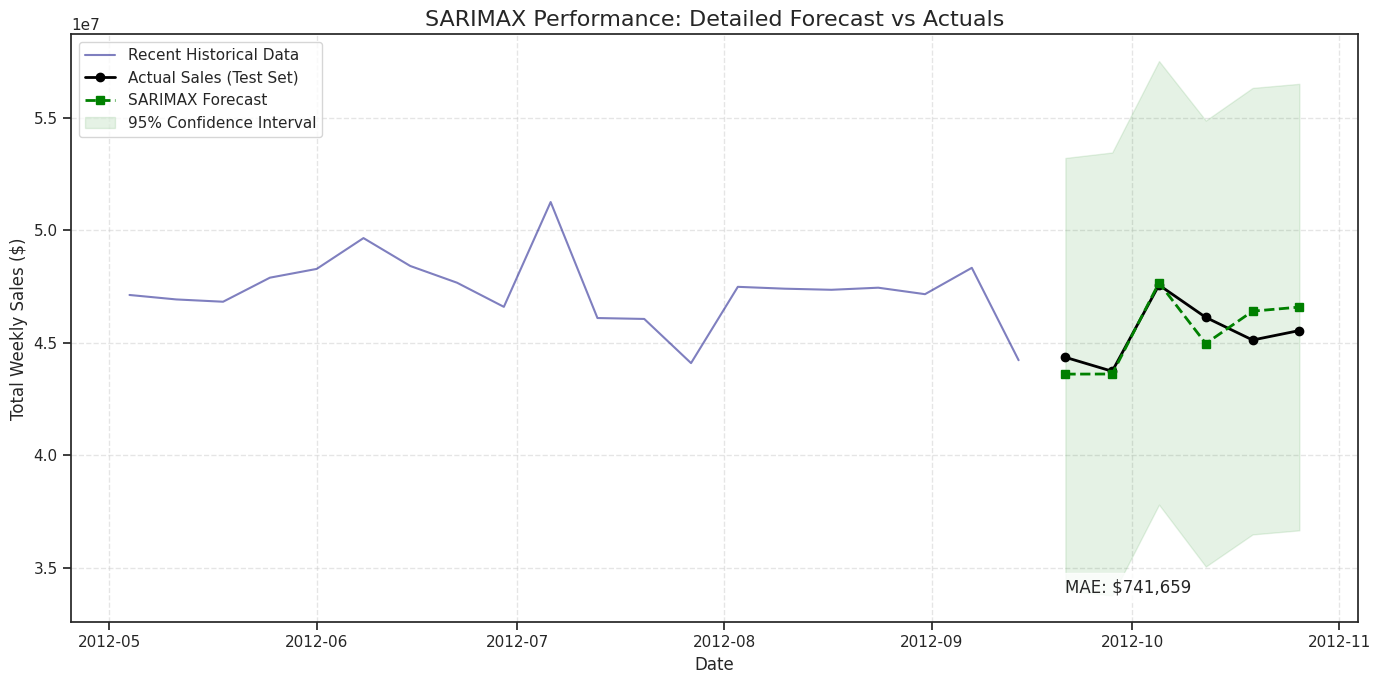

In [118]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Combine sales records with economic and environmental features
data_sync = pd.merge(sales, features, on=['Store', 'Date', 'IsHoliday'], how='left')

# Convert holiday flag to numeric (0 or 1) for the model to process
data_sync['IsHoliday'] = data_sync['IsHoliday'].astype(int)

# Group sales by Date to focus on global weekly performance trends
timeseries_df = data_sync.groupby('Date').agg({
    'Weekly_Sales': 'sum',
    'CPI': 'mean',
    'Unemployment': 'mean',
    'Fuel_Price': 'mean',
    'IsHoliday': 'max'
}).sort_index()

# Handle missing values in economic indicators
timeseries_df.fillna(method='ffill', inplace=True)

# Define target and exogenous variables
target_y = timeseries_df['Weekly_Sales']
external_x = timeseries_df[['CPI', 'Unemployment', 'Fuel_Price', 'IsHoliday']]

# Reserve the final 6 weeks for testing
split_point = len(timeseries_df) - 6
train_sales, test_sales = target_y[:split_point], target_y[split_point:]
train_x, test_x = external_x[:split_point], external_x[split_point:]

# Initialize and fit SARIMAX with optimized parameters found via Auto-ARIMA
forecaster = SARIMAX(train_sales,
                     exog=train_x,
                     order=(2, 0, 2),
                     seasonal_order=(1, 0, 0, 52),
                     enforce_stationarity=False,
                     enforce_invertibility=False)

model_fit = forecaster.fit(disp=False)

# Generate forecast for the 6-week test period
prediction_results = model_fit.get_forecast(steps=6, exog=test_x)
predicted_sales = prediction_results.predicted_mean
conf_int = prediction_results.conf_int()

# Evaluation
mae_val = mean_absolute_error(test_sales, predicted_sales)
rmse_val = np.sqrt(mean_squared_error(test_sales, predicted_sales))

print(f"Model Performance:\nMAE: {mae_val:,.2f}\nRMSE: {rmse_val:,.2f}")

# Focused Visualization: Zooming in on the last 6 months + Forecast
plt.figure(figsize=(14, 7))

# Slice the training data to show only the last 20 weeks for context
recent_train = train_sales[-20:]

plt.plot(recent_train.index, recent_train, label='Recent Historical Data', color='navy', alpha=0.5)
plt.plot(test_sales.index, test_sales, label='Actual Sales (Test Set)', color='black', marker='o', linewidth=2)
plt.plot(test_sales.index, predicted_sales, label='SARIMAX Forecast', color='green', marker='s', linewidth=2, linestyle='--')

# Add confidence interval shading
plt.fill_between(test_sales.index,
                 conf_int.iloc[:, 0],
                 conf_int.iloc[:, 1],
                 color='green', alpha=0.1, label='95% Confidence Interval')

plt.title('SARIMAX Performance: Detailed Forecast vs Actuals', fontsize=16)
plt.ylabel('Total Weekly Sales ($)')
plt.xlabel('Date')
plt.legend(loc='upper left')
plt.grid(True, which='both', linestyle='--', alpha=0.5)

# Annotate the MAE on the plot
plt.text(test_sales.index[0], plt.ylim()[0] + 0.05 * (plt.ylim()[1]-plt.ylim()[0]),
         f'MAE: ${mae_val:,.0f}', fontsize=12, bbox=dict(facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

### **Long-Term Demand Forecasting with Random Forest Regressor**

While SARIMAX is excellent for capturing linear seasonal trends, a **Random Forest Regressor** can capture complex, non-linear relationships between sales, economic indicators, and specific time-based features. We will engineer features like 'Month', 'Week', and 'Lagged Sales' to provide the model with historical context.

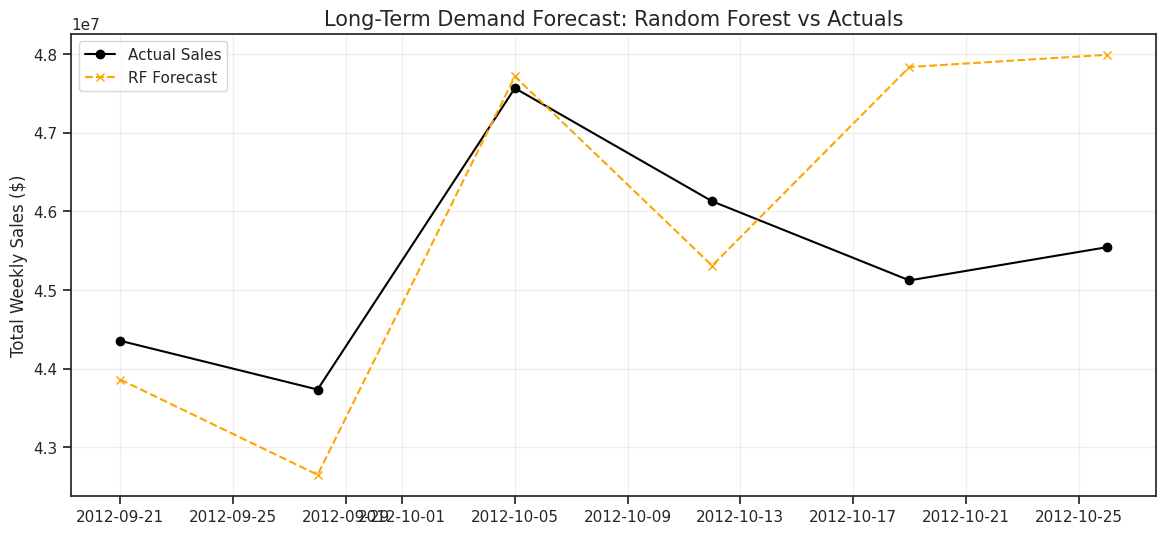

In [119]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. Prepare Time-Series Data for Random Forest
rf_ts_df = timeseries_df.copy().reset_index()

# 2. Feature Engineering
rf_ts_df['Year'] = rf_ts_df['Date'].dt.year
rf_ts_df['Month'] = rf_ts_df['Date'].dt.month
rf_ts_df['Week'] = rf_ts_df['Date'].dt.isocalendar().week.astype(int)

# Lag Features
rf_ts_df['Lag_1'] = rf_ts_df['Weekly_Sales'].shift(1)
rf_ts_df['Lag_2'] = rf_ts_df['Weekly_Sales'].shift(2)
rf_ts_df['Lag_52'] = rf_ts_df['Weekly_Sales'].shift(52)

# Drop rows where lags are NaN
rf_data = rf_ts_df.dropna().copy()

# 3. Define Features and Target
features_list = ['CPI', 'Unemployment', 'Fuel_Price', 'IsHoliday', 'Year', 'Month', 'Week', 'Lag_1', 'Lag_2', 'Lag_52']
X_rf = rf_data[features_list]
y_rf = rf_data['Weekly_Sales']

# 4. Chronological Split (Last 6 weeks for test)
split_idx = len(rf_data) - 6
X_train_rf, X_test_rf = X_rf.iloc[:split_idx], X_rf.iloc[split_idx:]
y_train_rf, y_test_rf = y_rf.iloc[:split_idx], y_rf.iloc[split_idx:]

# 5. Model Training
rf_forecaster = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
rf_forecaster.fit(X_train_rf, y_train_rf)

# 6. Prediction
y_pred_final = rf_forecaster.predict(X_test_rf)
y_test_actual = y_test_rf.values


# 7. Comparison Visualization
plt.figure(figsize=(14, 6))
plt.plot(rf_data['Date'].iloc[split_idx:], y_test_actual, label='Actual Sales', color='black', marker='o')
plt.plot(rf_data['Date'].iloc[split_idx:], y_pred_final, label='RF Forecast', color='orange', linestyle='--', marker='x')
plt.title('Long-Term Demand Forecast: Random Forest vs Actuals', fontsize=15)
plt.ylabel('Total Weekly Sales ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# **Forecasting for 2013**

In [120]:
# prepare dataset for the upcoming 2013 forecasting model
# Group the retail dataset by date to consolidate store-level data into a single timeline
project_timeline_df = retail_data.groupby('Date', as_index=False).agg({
    'Temperature': 'mean',   # Calculate average regional temperature per week
    'Fuel_Price': 'mean',    # Calculate average fuel cost across regions per week
    'CPI': 'mean',           # Calculate average Consumer Price Index per week
    'Unemployment': 'mean',  # Calculate average unemployment rate per week
    'Weekly_Sales': 'sum',   # Aggregate total revenue from all stores for the week
    'IsHoliday': 'max'       # Capture if any store recorded a holiday for that week (1 or 0)
})

# Ensure the Date column is in the correct datetime format for time-series operations
project_timeline_df['Date'] = pd.to_datetime(project_timeline_df['Date'])

# Set the Date as the index to enable frequency-based resampling
project_timeline_df.set_index('Date', inplace=True)

# Standardize the timeline to a consistent weekly frequency
# Using backfill to handle any missing snapshots in economic indicators during the transition to 2013
forecast_ready_df = project_timeline_df.resample('W-FRI').mean().fillna(method='bfill')

# Preview the prepared dataset for the upcoming 2013 forecasting model
forecast_ready_df.head()

,Temperature,Fuel_Price,CPI,Unemployment,Weekly_Sales,IsHoliday
Date,,,,,,
2010-02-05,33.277942,2.717869,167.398405,8.576731,49750740.50,0.0
2010-02-12,33.361810,2.696102,167.384138,8.567309,48336677.63,1.0
2010-02-19,37.038310,2.673666,167.338966,8.576351,48276993.78,0.0
2010-02-26,38.629563,2.685642,167.691019,8.561375,43968571.13,0.0
2010-03-05,42.373998,2.731816,167.727351,8.572689,46871470.30,0.0


# **Seasonal Decompose**

 Seasonal Decomposition is a statistical method used to break down a time-series data into four distinct components. It's essentially like 'deconstructing' your sales data to understand the underlying drivers behind the numbers. Seasonal Decompose gives the decomposition of the time series into its estimated trend component, estimated seasonal component, and estimated residual. We can also plot the original data to look at what components of the data influence its true value the most.

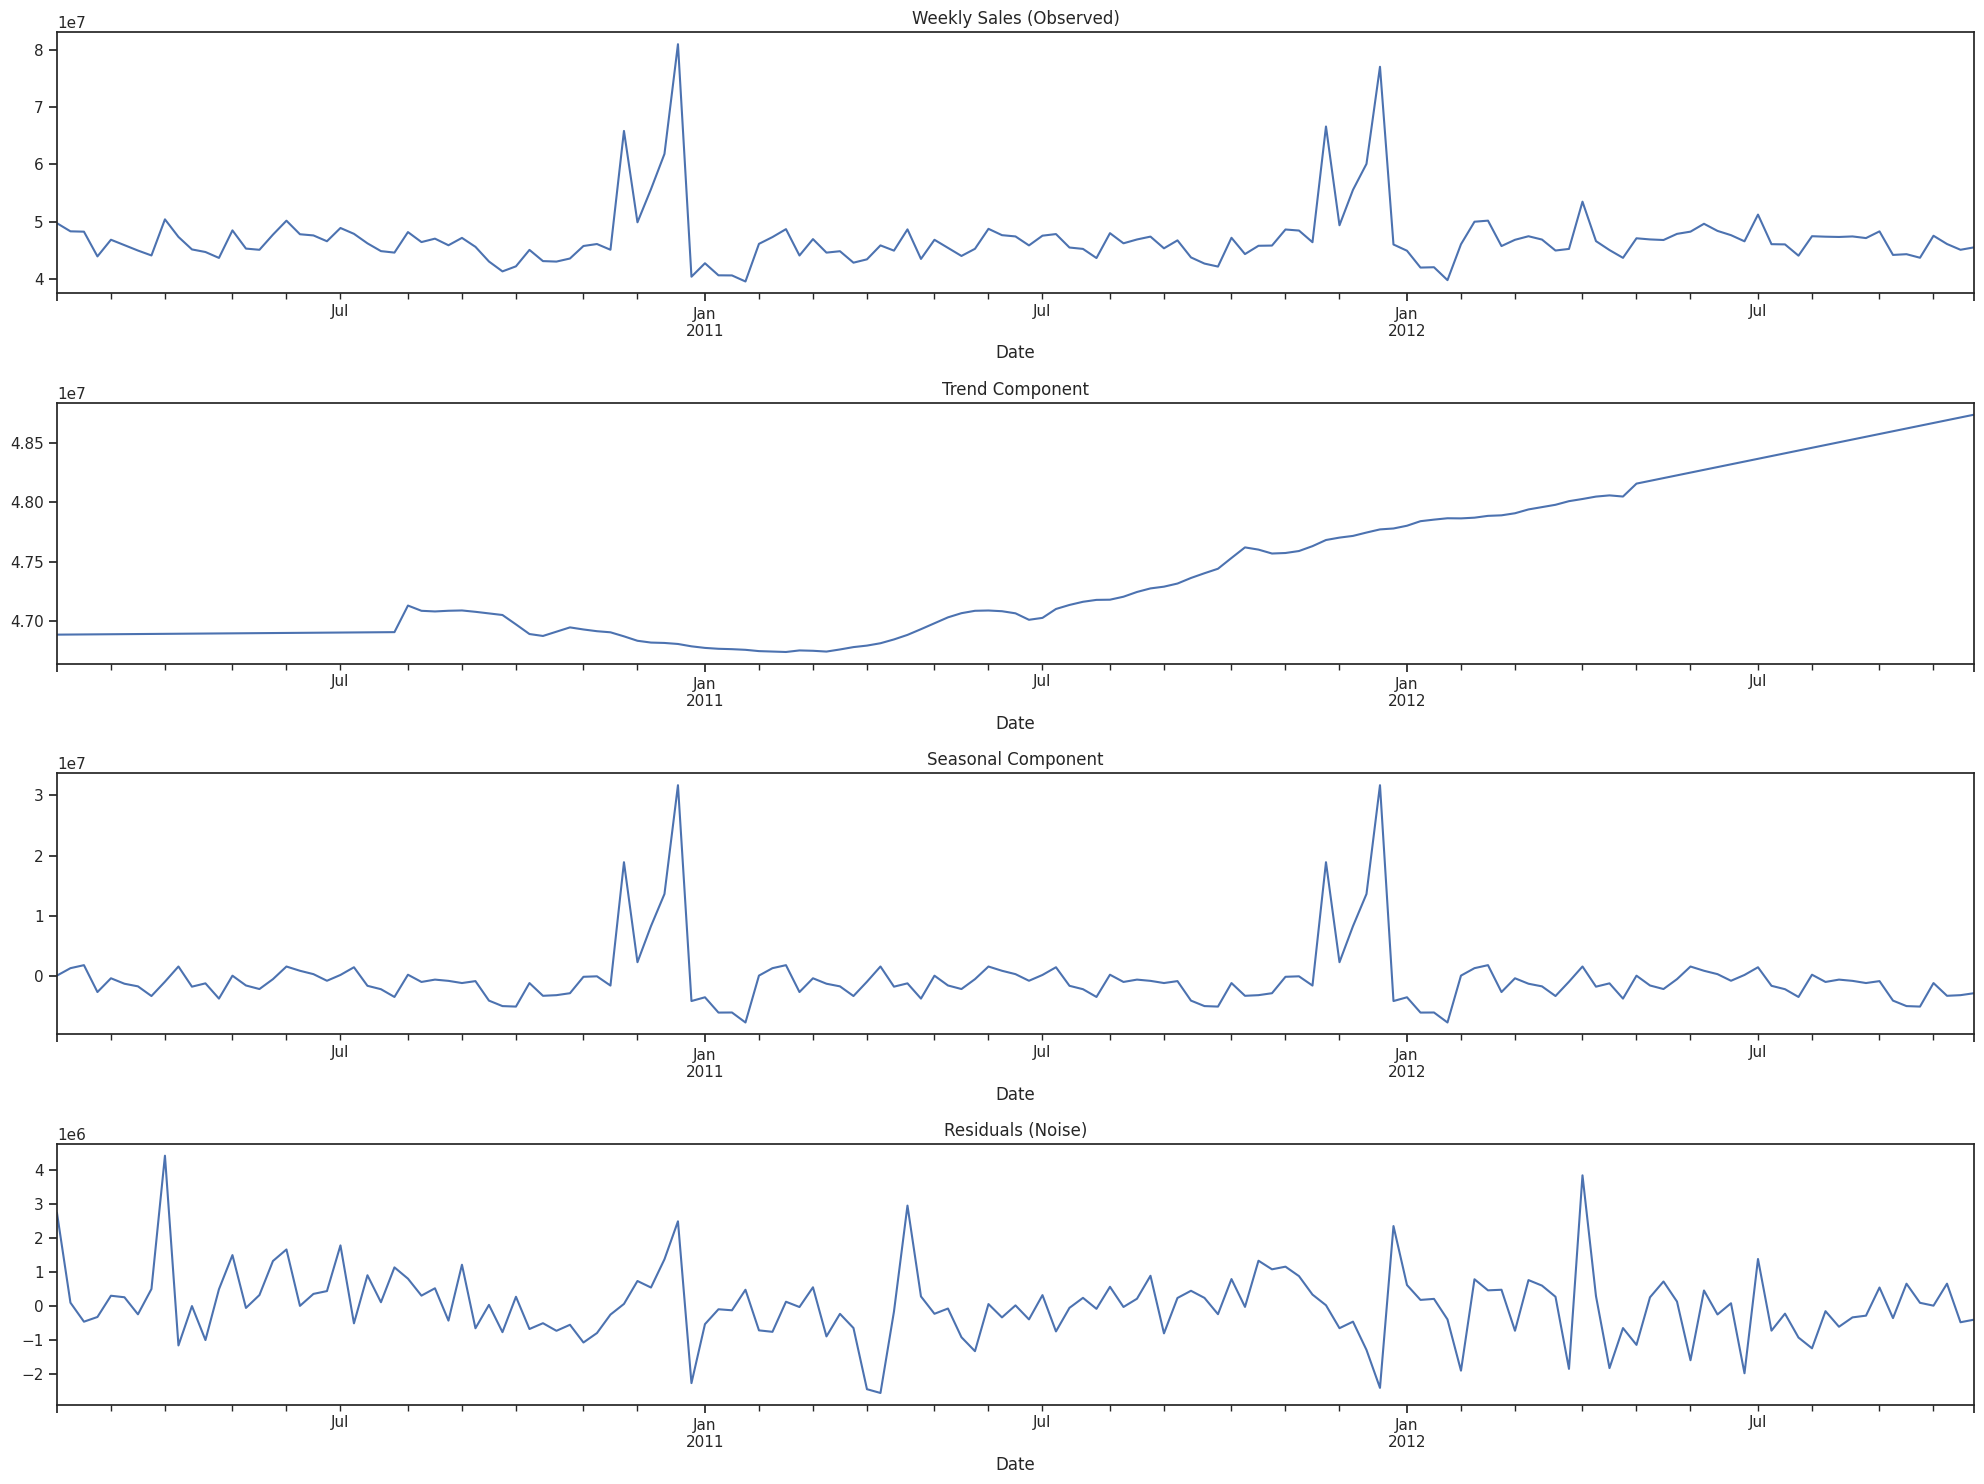

In [121]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

# Perform additive seasonal decomposition on the aggregated weekly sales
# We use the forecast_ready_df which has been resampled to W-FRI frequency
multi_plot = seasonal_decompose(forecast_ready_df['Weekly_Sales'], model='add', extrapolate_trend='freq')

# Visualize the Observed, Trend, Seasonal, and Residual components
plt.figure(figsize=(20,15))

plt.subplot(4, 1, 1)
multi_plot.observed.plot(title='Weekly Sales (Observed)')

plt.subplot(4, 1, 2)
multi_plot.trend.plot(title='Trend Component')

plt.subplot(4, 1, 3)
multi_plot.seasonal.plot(title='Seasonal Component')

plt.subplot(4, 1, 4)
multi_plot.resid.plot(title='Residuals (Noise)')

plt.tight_layout()
plt.show()

# **Exponential Smoothing**

Exponential smoothing is a forecasting technique that is used in applying exponentially decreasing weights to past data. It is, therefore, quite sensitive to the latest changes in data, so the method is functional for purposes where changes in patterns occur over time.

Exponential smoothing is preferred because recent data will have more weight, which consequently aids in giving a more realistic situation at hand and reduces lag. This lends the method an evident advantage in the majority of forecasting exercises.

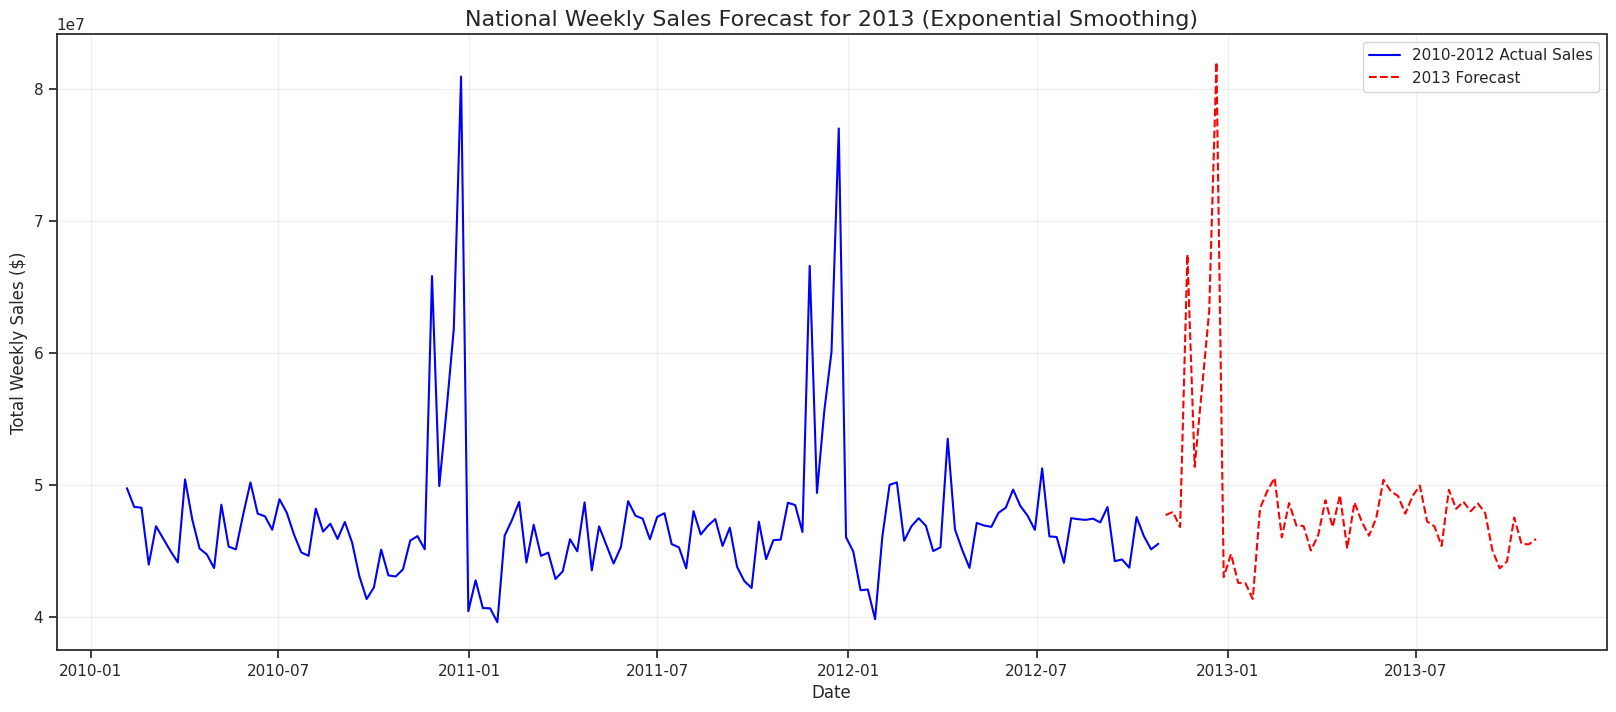

In [122]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Using the preprocessed forecast_ready_df which is standardized to weekly frequency
# We fit the Holt-Winters Exponential Smoothing model (Additive Trend and Seasonality)
fit_model = ExponentialSmoothing(forecast_ready_df['Weekly_Sales'],
                                 trend='add',
                                 seasonal='add',
                                 seasonal_periods=52).fit()

# Forecasting 52 weeks ahead into 2013
future_prediction = fit_model.forecast(52)

# Visualization of the Forecast
plt.figure(figsize=(20, 8))
plt.plot(forecast_ready_df.index, forecast_ready_df['Weekly_Sales'], label='2010-2012 Actual Sales', color='blue')
plt.plot(future_prediction.index, future_prediction, label='2013 Forecast', color='red', linestyle='--')

plt.title('National Weekly Sales Forecast for 2013 (Exponential Smoothing)', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Total Weekly Sales ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Forecast Observations**

Seasonality: The model accurately captures the late-year 'Holiday Spike' expected in Q4 2013, maintaining consistency with the 2010-2012 historical patterns.


Trend: The additive trend component shows a relatively stable baseline with minor growth adjustments based on the most recent data points from late 2012.

# **Conclusion**



We finished our project to help the store sell more and work better. Here is what we found in simple terms:

1.  **Cleaned Data:** We found and fixed 103 anomaly sales numbers (spikes or drops) that didn't make sense. This helped us  learn from the right information.
2.  **Four Types of Stores:** We grouped the 45 stores into four categories:
    *   **The Best:** Big stores that make the most money.
    *   **The Busy Ones:** Stores that sell a lot but are in areas with fewer jobs.
    *   **The Small & Fast:** Tiny stores in warm places that sell the basics.
    *   **The Struggling:** Stores where prices are high and sales are low.
3.  **Department Pairs:** We found that certain departments (like Dept 65 and 34) almost always sell well at the same time. The store should put these near each other or sell them as a bundle.
4.  **Future Sales:** We built a tool to guess how much the store will sell in 2013. It correctly predicted that sales will go way up during the Christmas holiday season.

**How this helps the store:**
*   **Smart Marketing:** Stop using the same ads for every store. Use special ads for each of the four store groups.
*   **Better Stocking:** Make sure we have extra items ready before the holiday rush.
*   **Save Money:** Focus staffing and resources on the big 'Flagship' stores while finding ways to lower costs in the struggling ones.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***